###  Installation de l'environnement

In [1]:
%pip install plotly-express

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


### Connexion à la DB DuckDB

In [3]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

### Connexion à la DB / Import des Data


In [4]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [5]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 6 tables in the database:

1. all_events
2. loaded_files
3. user_events
4. user_events_11_2019
5. user_segments_11_2019_kmeans
6. user_segments_kmeans


### Import de la table DuckDB

In [6]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "user_events_11_2019"
TABLE_SEGMENTS = "user_segments_11_2019"
SAMPLE_USER_PERCENT = 0.2
BATCH_SIZE = 1000 

In [7]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────────────────────┐
│             name             │
│           varchar            │
├──────────────────────────────┤
│ all_events                   │
│ loaded_files                 │
│ user_events                  │
│ user_events_11_2019          │
│ user_segments_11_2019_kmeans │
│ user_segments_kmeans         │
└──────────────────────────────┘



In [8]:
# Examine the all_events table
print(f"First 10 rows of {TABLE_EVENTS} table:")
user_events = con.sql(f"""
    SELECT * FROM {TABLE_EVENTS} ORDER BY RANDOM() LIMIT 30000
""")
user_events.show()
user_events_df = user_events.df()


First 10 rows of user_events_11_2019 table:
┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬────────────────────┬────────────────────┬─────────────────────┬──────────────────────┬─────────────────────┬───────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │    total_spent     │     avg_basket     │   last_event_time   │   conversion_rate    │   purchase_ratio    │ days_since_last_event │
│  varchar  │    int64     │   double    │     double      │         double          │       double       │       double       │      timestamp      │        double        │       double        │         int64         │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼────────────────────┼────────────────────┼─────────────────────┼──────────────────────┼─────────────────────┼───────────────────────┤
│ 529081423 │           23 │        12.0 │             5.0 │      59855.5454

# Matrice de Corréaltion

Text(0.5, 1.0, 'Matrice de corrélation des variables numériques')

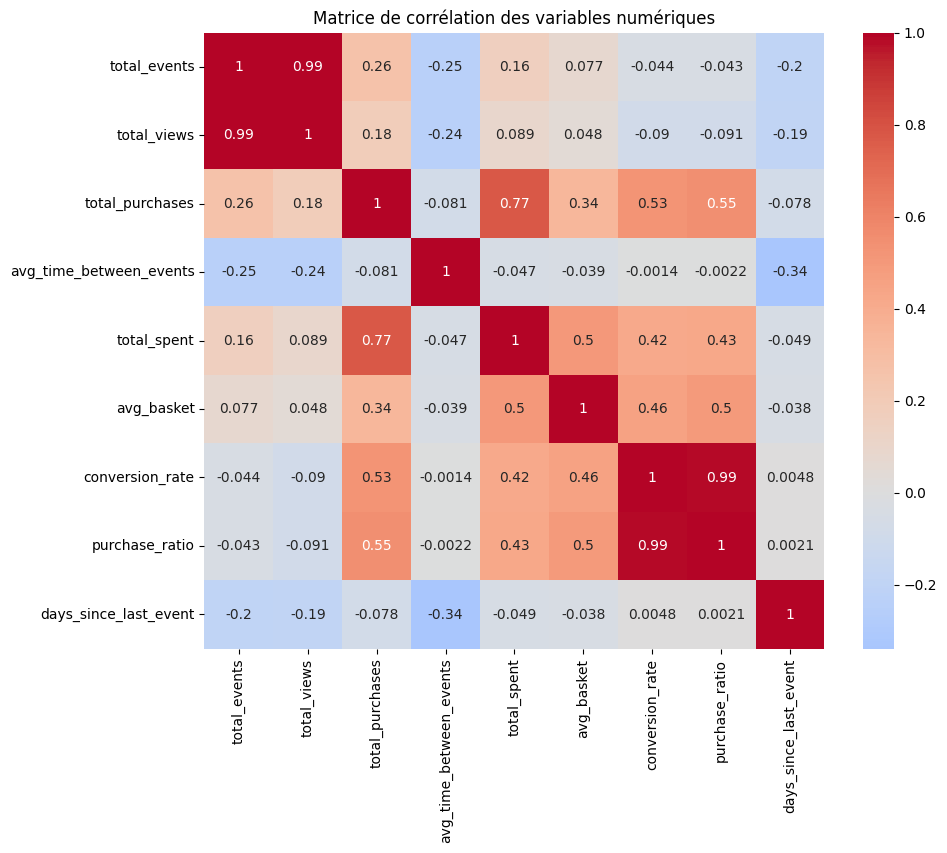

In [9]:
# Correlation between numerical columns
numeric_columns = user_events_df.select_dtypes(include=[np.number]).columns
correlation = user_events_df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des variables numériques')



# Nettoyage des clonnes inutiles

In [10]:
user_events_df.drop(columns=["days_since_last_event","conversion_rate","avg_time_between_events","purchase_ratio"], inplace=True)

# Traitements des Outliers

In [11]:
def remove_outliers_by_quantile(df, target_name, lower_quantile=0, upper_quantile=0.75, clean_cols=None):
    """
    Traite les outliers de chaque colonne numérique en remplaçant les valeurs aberrantes
    par les seuils définis par les quantiles.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame contenant les données à traiter
    target_name : str
        Nom de la colonne cible à exclure du traitement (ex: 'segment', 'CLASS')
    lower_quantile : float, default=0
        Quantile inférieur pour définir le seuil bas (valeurs en dessous seront remplacées)
    upper_quantile : float, default=0.75
        Quantile supérieur pour définir le seuil haut (valeurs au-dessus seront remplacées)
    clean_cols : list or None, default=None
        Liste des colonnes à traiter. Si None, traite toutes les colonnes numériques.
    
    Returns:
    --------
    df_cleaned : pd.DataFrame
        DataFrame avec les outliers traités
    stats : dict
        Dictionnaire contenant les statistiques de traitement pour chaque colonne
    """
    df_cleaned = df.copy()
    stats = {}
    
    # Colonnes à exclure du traitement
    exclude_cols = [target_name, 'last_event_time', 'user_id', 'event_time']
    
    # Sélectionner uniquement les colonnes numériques
    numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    # Si clean_cols est spécifié, filtrer pour ne garder que ces colonnes
    if clean_cols is not None:
        cols_to_clean = [col for col in clean_cols if col in numeric_cols]
        print(f"Colonnes sélectionnées pour le nettoyage: {cols_to_clean}")
    else:
        cols_to_clean = numeric_cols
    
    print(f"Traitement des outliers avec quantiles [{lower_quantile}, {upper_quantile}]")
    print("=" * 70)
    
    for col in numeric_cols:
        # Calculer les seuils pour toutes les colonnes (pour les stats)
        lower_threshold = df_cleaned[col].quantile(lower_quantile)
        upper_threshold = df_cleaned[col].quantile(upper_quantile)
        
        # Compter les outliers avant traitement
        lower_outliers = (df_cleaned[col] < lower_threshold).sum()
        upper_outliers = (df_cleaned[col] > upper_threshold).sum()
        total_outliers = lower_outliers + upper_outliers
        
        # Stocker les statistiques pour toutes les colonnes
        stats[col] = {
            'lower_threshold': lower_threshold,
            'upper_threshold': upper_threshold,
            'lower_outliers_count': lower_outliers,
            'upper_outliers_count': upper_outliers,
            'total_outliers': total_outliers,
            'outliers_percentage': (total_outliers / len(df_cleaned)) * 100,
            'cleaned': col in cols_to_clean  # Marquer si la colonne a été nettoyée
        }
        
        # Remplacer les outliers UNIQUEMENT pour les colonnes sélectionnées
        if col in cols_to_clean:
            df_cleaned[col] = df_cleaned[col].clip(lower=lower_threshold, upper=upper_threshold)
            
            # Afficher les résultats si des outliers ont été traités
            if total_outliers > 0:
                print(f"\n✓ {col} [NETTOYÉE]:")
                print(f"  Seuil inférieur ({lower_quantile*100}%): {lower_threshold:.2f}")
                print(f"  Seuil supérieur ({upper_quantile*100}%): {upper_threshold:.2f}")
                print(f"  Outliers bas remplacés: {lower_outliers}")
                print(f"  Outliers hauts remplacés: {upper_outliers}")
                print(f"  Total: {total_outliers} ({stats[col]['outliers_percentage']:.2f}%)")
        else:
            # Juste afficher les stats sans nettoyer
            if total_outliers > 0:
                print(f"\n○ {col} [NON NETTOYÉE]:")
                print(f"  Outliers détectés: {total_outliers} ({stats[col]['outliers_percentage']:.2f}%)")
    
    print("\n" + "=" * 70)
    total_cleaned_outliers = sum([s['total_outliers'] for s in stats.values() if s['cleaned']])
    total_all_outliers = sum([s['total_outliers'] for s in stats.values()])
    print(f"Total d'outliers traités: {total_cleaned_outliers}/{total_all_outliers}")
    
    return df_cleaned, stats


def plot_outlier_treatment_comparison(df_original, df_cleaned, target_name, stats):
    """
    Visualise l'effet du traitement des outliers sur les données.
    Affiche TOUTES les colonnes, mais marque celles qui ont été nettoyées.
    
    Parameters:
    -----------
    df_original : pd.DataFrame
        DataFrame original avant traitement
    df_cleaned : pd.DataFrame
        DataFrame après traitement
    target_name : str
        Nom de la colonne cible
    stats : dict
        Statistiques retournées par remove_outliers_by_quantile
    """
    # Toutes les colonnes avec stats
    all_cols = list(stats.keys())
    
    if not all_cols:
        print("Aucune colonne n'a été analysée")
        return
    
    n_cols = len(all_cols)
    n_rows = (n_cols + 2) // 3  # 3 colonnes par ligne
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(all_cols):
        ax = axes[idx]
        
        # Boxplot avant/après
        data_to_plot = [
            df_original[col].dropna(),
            df_cleaned[col].dropna()
        ]
        
        bp = ax.boxplot(data_to_plot, labels=['Avant', 'Après'], patch_artist=True)
        
        # Colorer différemment selon si la colonne a été nettoyée ou non
        if stats[col]['cleaned']:
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            title_prefix = "✓ NETTOYÉE"
        else:
            bp['boxes'][0].set_facecolor('lightgray')
            bp['boxes'][1].set_facecolor('lightgray')
            title_prefix = "○ NON NETTOYÉE"
        
        # Ajouter les seuils
        lower = stats[col]['lower_threshold']
        upper = stats[col]['upper_threshold']
        ax.axhline(y=lower, color='blue', linestyle='--', alpha=0.5, label=f'Seuil bas: {lower:.2f}')
        ax.axhline(y=upper, color='red', linestyle='--', alpha=0.5, label=f'Seuil haut: {upper:.2f}')
        
        ax.set_title(f'{title_prefix} - {col}\n{stats[col]["total_outliers"]} outliers ({stats[col]["outliers_percentage"]:.1f}%)')
        ax.set_ylabel('Valeur')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Masquer les axes vides
    for idx in range(len(all_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Comparaison avant/après traitement des outliers', fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()

In [12]:
## Traiter uniquement certaines colonnes
#user_events_cleaned, outlier_stats = remove_outliers_by_quantile(
#    user_events_df, 
#    target_name='segment',
#    lower_quantile=0, 
#    upper_quantile=1,
#    clean_cols=['total_events', 'purchase_count', 'avg_price', 'avg_basket']  # Seulement ces colonnes seront nettoyées
#)
#
## La visualisation affichera TOUTES les colonnes, mais marquera celles qui ont été nettoyées
#plot_outlier_treatment_comparison(user_events_df, user_events_cleaned, 'segment', outlier_stats)
#
## Afficher les statistiques détaillées
#print("\nStatistiques détaillées par colonne:")
#for col, stat in outlier_stats.items():
#    status = "NETTOYÉE" if stat['cleaned'] else "NON NETTOYÉE"
#    print(f"\n{col} [{status}]: {stat}")

In [13]:
user_events_cleaned = user_events_df.copy()

In [14]:
user_events_cleaned.describe()

,total_events,total_views,total_purchases,total_spent,avg_basket,last_event_time
count,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000
mean,43.733633,41.11540,0.587333,180.104619,70.977297,2019-11-21 19:08:10.107699
min,10.000000,1.00000,0.000000,0.000000,0.000000,2019-11-01 00:11:14
25%,15.000000,14.00000,0.000000,0.000000,0.000000,2019-11-16 17:44:22.250000
50%,24.000000,23.00000,0.000000,0.000000,0.000000,2019-11-23 03:56:32.500000
75%,48.000000,45.00000,1.000000,15.420000,12.896250,2019-11-28 09:16:23.500000
max,2396.000000,2295.00000,109.000000,64754.980000,2573.810000,2019-11-30 23:59:53
std,61.300795,58.93307,2.058036,962.157709,198.317657,NaN


### Normalisation et Standardisation des données

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sélectionner les features numériques
numeric_features = user_events_cleaned.drop(columns=["last_event_time"])

# Option 1: Standardisation (Z-score normalization) - moyenne=0, écart-type=1
print("Standardisation des données...")
std_scaler = StandardScaler()
X_standardized = std_scaler.fit_transform(numeric_features)
print(f"Shape après standardisation: {X_standardized.shape}")
print(f"Moyenne après standardisation: {X_standardized.mean(axis=0)[:3]}...")  # ~0
print(f"Écart-type après standardisation: {X_standardized.std(axis=0)[:3]}...")  # ~1

# Choisir quelle méthode utiliser pour le clustering
# Recommandation: StandardScaler pour KMeans (plus robuste aux outliers)
X_num_scaled = X_standardized  # ou X_normalized selon votre choix

print("\n" + "="*70)
print(f"Méthode choisie: {'Standardisation' if X_num_scaled is X_standardized else 'Normalisation'}")
print(f"Shape finale: {X_num_scaled.shape}")

Standardisation des données...
Shape après standardisation: (30000, 6)
Moyenne après standardisation: [-6.54646707e-16  5.68434189e-17 -1.32634644e-17]...
Écart-type après standardisation: [1. 1. 1.]...

Méthode choisie: Standardisation
Shape finale: (30000, 6)


In [16]:
X_num_scaled.shape

(30000, 6)

In [17]:
X_num_scaled

array([[-0.74970138, -0.55030601, -0.59586214,  0.20051809,  0.18703626,
         1.45769936],
       [ 1.07947682, -0.43611309, -0.40920661, -0.28539005, -0.18719137,
        -0.35790298],
       [-1.19590568, -0.35454672, -0.32436319, -0.28539005, -0.18719137,
        -0.35790298],
       ...,
       [-0.53440432,  0.55899663,  0.62588314, -0.28539005, -0.18719137,
        -0.35790298],
       [ 1.14417175, -0.55030601, -0.56192477,  0.68642623, -0.10560255,
        -0.15998487],
       [ 1.44682673, -0.53399273, -0.51101872, -0.28539005, -0.18719137,
        -0.35790298]], shape=(30000, 6))

In [18]:
user_events_df.describe()

,total_events,total_views,total_purchases,total_spent,avg_basket,last_event_time
count,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000
mean,43.733633,41.11540,0.587333,180.104619,70.977297,2019-11-21 19:08:10.107699
min,10.000000,1.00000,0.000000,0.000000,0.000000,2019-11-01 00:11:14
25%,15.000000,14.00000,0.000000,0.000000,0.000000,2019-11-16 17:44:22.250000
50%,24.000000,23.00000,0.000000,0.000000,0.000000,2019-11-23 03:56:32.500000
75%,48.000000,45.00000,1.000000,15.420000,12.896250,2019-11-28 09:16:23.500000
max,2396.000000,2295.00000,109.000000,64754.980000,2573.810000,2019-11-30 23:59:53
std,61.300795,58.93307,2.058036,962.157709,198.317657,NaN


In [19]:
tmp_user_events_df = user_events_df.copy()
tmp_user_events_df.reset_index(drop=True, inplace=True)

In [20]:
# Replace for Using category embeddings
#X_final = np.hstack([X_num_scaled, X_emb_scaled])
X_final = X_num_scaled

### Choix du Nombre de Clusters, Analyse du Coude et Analyse de la struture des clusters

Analyse du coude pour déterminer le nombre optimal de clusters...


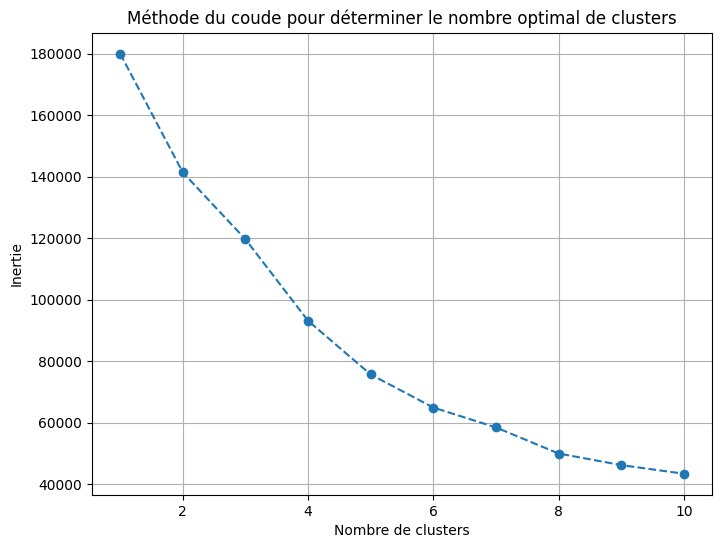

In [21]:

# Analyse du Coude (Elbow Method)
print("Analyse du coude pour déterminer le nombre optimal de clusters...")

inertia = []
cluster_range = range(1, 11)  # Test cluster counts from 1 to 10

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_final)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, inertia, marker='o', linestyle='--')
plt.title("Méthode du coude pour déterminer le nombre optimal de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid(True)
plt.show()

### Fit et Plot KMeans

In [22]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.offline as py
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, Birch
from sklearn.mixture import GaussianMixture
import pandas as pd


def kmeans_fit_and_plot_per_cluster(k, X_final, df):
    df_tmp = df.copy()
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_final)
    df_tmp["segment"] = clusters

    # --- Silhouette Analysis ---
    print("Silhouette Analysis...")
    silhouette_avg = silhouette_score(X_final, clusters)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(X_final, clusters)

    # Print silhouette score for each cluster
    for cluster in range(k):
        cluster_silhouette_avg = sample_silhouette_values[clusters == cluster].mean()
        print(f"Silhouette score for Cluster {cluster}: {cluster_silhouette_avg}")

    # Define consistent colors for clusters
    colormap = plt.colormaps.get_cmap("tab10")
    cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(k)]
    cluster_color_map = {i: cluster_colors[i] for i in range(k)}  # Map cluster index to color

    # --- Silhouette Plot ---
    plt.figure(figsize=(10, 8))
    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cluster_color_map[i]
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    plt.title(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {k}")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks(np.arange(-0.1, 1.1, 0.1))
    plt.show()

    # --- PCA Scatter Plot (2D) ---
    print("Visualisation du clustering (2D)...")
    pca = PCA(n_components=2)
    X_pca_2d = pca.fit_transform(X_final)

    plt.figure(figsize=(10, 8))
    for i in range(k):
        cluster_points = X_pca_2d[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=cluster_color_map[i], label=f"Cluster {i}", s=10)

    plt.title(f"Visualisation des clusters utilisateurs (PCA 2D)- K = {k}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- PCA Scatter Plot (3D) ---
    print("Visualisation du clustering (3D)...")
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_final)

    # Prepare data for Plotly
    traces = []
    for i in range(k):
        cluster_points = X_pca_3d[clusters == i]
        trace = go.Scatter3d(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            z=cluster_points[:, 2],
            mode='markers',
            marker=dict(
                size=8,
                color=cluster_color_map[i],  # Use consistent cluster color
                opacity=0.8
            ),
            name=f"Cluster {i}"
        )
        traces.append(trace)

    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Plot of Clusters"
    )
    fig = go.Figure(data=traces, layout=layout)
    py.iplot(fig, filename='3d-scatter-colorscale')

    return df_tmp

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_stats(df, segment_column="segment"):
    """
    Plots statistics, distributions, and boxplots for clusters in the DataFrame.

    Parameters:
    - df: DataFrame containing the clustering results and features.
    - segment_column: Name of the column containing cluster segments.

    Returns:
    - stats: A dictionary containing descriptive statistics for each cluster.
    """
    # Ensure the segment column exists
    if segment_column not in df.columns:
        raise ValueError(f"Column '{segment_column}' not found in the DataFrame.")

    # Number of individuals per cluster
    cluster_counts = df[segment_column].value_counts().sort_index()
    print("Number of individuals per cluster:")
    print(cluster_counts)

    # Plot the distribution of individuals per cluster
    plt.figure(figsize=(10, 6))
    cluster_counts.plot(kind="bar", color="skyblue", alpha=0.8)
    plt.title("Distribution of Individuals per Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Number of Individuals")
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    # Descriptive statistics for each cluster
    stats = {}
    for cluster in cluster_counts.index:
        cluster_data = df[df[segment_column] == cluster]
        cluster_stats = cluster_data.describe()
        stats[cluster] = cluster_stats
        print(f"\nDescriptive statistics for Cluster {cluster}:")
        print(cluster_stats)

    # Boxplots for each column grouped by cluster
    numeric_columns = df.select_dtypes(include=["number"]).columns
    numeric_columns = [col for col in numeric_columns if col != segment_column]

    for col in numeric_columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=segment_column, y=col, data=df, palette="Set3")
        plt.title(f"Boxplot of {col} by Cluster")
        plt.xlabel("Cluster")
        plt.ylabel(col)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()

    return stats

In [24]:
def gmm_fit_and_plot_per_cluster(n_components, X_final, df, covariance_type='full'):
    """
    Fit Gaussian Mixture Model and plot clustering results.
    
    Parameters:
    - n_components: Number of mixture components (clusters)
    - X_final: Feature matrix
    - df: Original dataframe
    - covariance_type: Type of covariance parameters ('full', 'tied', 'diag', 'spherical')
    
    Returns:
    - df_tmp: DataFrame with cluster assignments
    """
    df_tmp = df.copy()
    gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, random_state=42)
    clusters = gmm.fit_predict(X_final)
    df_tmp["segment"] = clusters
    
    # --- Silhouette Analysis ---
    print("Silhouette Analysis for GMM...")
    silhouette_avg = silhouette_score(X_final, clusters)
    print(f"For n_components = {n_components}, the average silhouette_score is: {silhouette_avg}")
    print(f"BIC: {gmm.bic(X_final):.2f}, AIC: {gmm.aic(X_final):.2f}")
    
    sample_silhouette_values = silhouette_samples(X_final, clusters)
    
    # Print silhouette score for each cluster
    for cluster in range(n_components):
        cluster_silhouette_avg = sample_silhouette_values[clusters == cluster].mean()
        print(f"Silhouette score for Cluster {cluster}: {cluster_silhouette_avg}")
    
    # Define consistent colors for clusters
    colormap = plt.colormaps.get_cmap("tab10")
    cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(n_components)]
    cluster_color_map = {i: cluster_colors[i] for i in range(n_components)}
    
    # --- Silhouette Plot ---
    plt.figure(figsize=(10, 8))
    y_lower = 10
    for i in range(n_components):
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cluster_color_map[i]
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    plt.title(f"Silhouette analysis for GMM clustering with n_components = {n_components}")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks(np.arange(-0.1, 1.1, 0.1))
    plt.show()
    
    # --- PCA Scatter Plot (2D) ---
    print("Visualisation du clustering (2D)...")
    pca = PCA(n_components=2)
    X_pca_2d = pca.fit_transform(X_final)
    
    plt.figure(figsize=(10, 8))
    for i in range(n_components):
        cluster_points = X_pca_2d[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=cluster_color_map[i], label=f"Cluster {i}", s=10)
    
    plt.title(f"Visualisation des clusters GMM (PCA 2D) - K = {n_components}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # --- PCA Scatter Plot (3D) ---
    print("Visualisation du clustering (3D)...")
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_final)
    
    traces = []
    for i in range(n_components):
        cluster_points = X_pca_3d[clusters == i]
        trace = go.Scatter3d(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            z=cluster_points[:, 2],
            mode='markers',
            marker=dict(
                size=8,
                color=cluster_color_map[i],
                opacity=0.8
            ),
            name=f"Cluster {i}"
        )
        traces.append(trace)
    
    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Plot of GMM Clusters"
    )
    fig = go.Figure(data=traces, layout=layout)
    py.iplot(fig, filename='3d-scatter-gmm')
    
    return df_tmp


def dbscan_fit_and_plot(eps, min_samples, X_final, df):
    """
    Fit DBSCAN and plot clustering results.
    
    Parameters:
    - eps: Maximum distance between two samples for them to be considered as in the same neighborhood
    - min_samples: Minimum number of samples in a neighborhood for a point to be considered as a core point
    - X_final: Feature matrix
    - df: Original dataframe
    
    Returns:
    - df_tmp: DataFrame with cluster assignments (-1 indicates noise)
    """
    df_tmp = df.copy()
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    clusters = dbscan.fit_predict(X_final)
    df_tmp["segment"] = clusters
    
    # Get unique clusters (excluding noise -1)
    unique_clusters = np.unique(clusters)
    n_clusters = len(unique_clusters[unique_clusters != -1])
    n_noise = len(clusters[clusters == -1])
    
    print(f"DBSCAN Results:")
    print(f"Number of clusters found: {n_clusters}")
    print(f"Number of noise points: {n_noise} ({100 * n_noise / len(clusters):.2f}%)")
    
    # --- Silhouette Analysis (only if we have at least 2 clusters and not all points are noise) ---
    if n_clusters >= 2 and n_noise < len(clusters):
        # For silhouette, we need to exclude noise points (-1)
        mask_no_noise = clusters != -1
        X_no_noise = X_final[mask_no_noise]
        clusters_no_noise = clusters[mask_no_noise]
        
        silhouette_avg = silhouette_score(X_no_noise, clusters_no_noise)
        print(f"Average silhouette_score (excluding noise): {silhouette_avg}")
        
        sample_silhouette_values = silhouette_samples(X_no_noise, clusters_no_noise)
        
        # Print silhouette score for each cluster
        for cluster in unique_clusters[unique_clusters != -1]:
            cluster_mask = clusters_no_noise == cluster
            cluster_silhouette_avg = sample_silhouette_values[cluster_mask].mean()
            cluster_size = cluster_mask.sum()
            print(f"Silhouette score for Cluster {cluster} (size: {cluster_size}): {cluster_silhouette_avg}")
        
        # Define colors for clusters
        colormap = plt.colormaps.get_cmap("tab10")
        cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(len(unique_clusters))]
        cluster_color_map = {cluster: cluster_colors[idx] for idx, cluster in enumerate(unique_clusters)}
        
        # --- Silhouette Plot (excluding noise) ---
        plt.figure(figsize=(10, 8))
        y_lower = 10
        for cluster in sorted(unique_clusters[unique_clusters != -1]):
            cluster_mask = clusters_no_noise == cluster
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_mask]
            ith_cluster_silhouette_values.sort()
            
            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cluster_color_map[cluster]
            plt.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )
            
            plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(cluster))
            y_lower = y_upper + 10
        
        plt.title(f"Silhouette analysis for DBSCAN (eps={eps}, min_samples={min_samples})")
        plt.xlabel("The silhouette coefficient values")
        plt.ylabel("Cluster label")
        plt.axvline(x=silhouette_avg, color="red", linestyle="--")
        plt.yticks([])
        plt.xticks(np.arange(-0.1, 1.1, 0.1))
        plt.show()
    else:
        print("Not enough clusters for silhouette analysis")
        # Simple color map for visualization
        colormap = plt.colormaps.get_cmap("tab10")
        cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(len(unique_clusters))]
        cluster_color_map = {cluster: cluster_colors[idx] for idx, cluster in enumerate(unique_clusters)}
    
    # --- PCA Scatter Plot (2D) ---
    print("Visualisation du clustering (2D)...")
    pca = PCA(n_components=2)
    X_pca_2d = pca.fit_transform(X_final)
    
    plt.figure(figsize=(10, 8))
    for cluster in unique_clusters:
        cluster_points = X_pca_2d[clusters == cluster]
        label = f"Cluster {cluster}" if cluster != -1 else "Noise"
        marker = 'o' if cluster != -1 else 'x'
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                   c=cluster_color_map[cluster], label=label, s=10, marker=marker)
    
    plt.title(f"Visualisation DBSCAN (PCA 2D) - {n_clusters} clusters")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # --- PCA Scatter Plot (3D) ---
    print("Visualisation du clustering (3D)...")
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_final)
    
    traces = []
    for cluster in unique_clusters:
        cluster_points = X_pca_3d[clusters == cluster]
        label = f"Cluster {cluster}" if cluster != -1 else "Noise"
        trace = go.Scatter3d(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            z=cluster_points[:, 2],
            mode='markers',
            marker=dict(
                size=8 if cluster != -1 else 4,
                color=cluster_color_map[cluster],
                opacity=0.8,
                symbol='cross' if cluster == -1 else 'circle'
            ),
            name=label
        )
        traces.append(trace)
    
    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Plot of DBSCAN Clusters"
    )
    fig = go.Figure(data=traces, layout=layout)
    py.iplot(fig, filename='3d-scatter-dbscan')
    
    return df_tmp


def birch_fit_and_plot_per_cluster(n_clusters, X_final, df, threshold=0.5, branching_factor=50):
    """
    Fit BIRCH clustering and plot results.
    
    Parameters:
    - n_clusters: Number of clusters (can be None for automatic determination)
    - X_final: Feature matrix
    - df: Original dataframe
    - threshold: Maximum radius of the subcluster obtained by merging a new sample
    - branching_factor: Maximum number of CF subclusters in each node
    
    Returns:
    - df_tmp: DataFrame with cluster assignments
    """
    df_tmp = df.copy()
    birch = Birch(n_clusters=n_clusters, threshold=threshold, branching_factor=branching_factor)
    clusters = birch.fit_predict(X_final)
    df_tmp["segment"] = clusters
    
    # Determine actual number of clusters
    unique_clusters = np.unique(clusters)
    k = len(unique_clusters)
    
    print(f"BIRCH Results:")
    print(f"Number of clusters found: {k}")
    
    # --- Silhouette Analysis ---
    print("Silhouette Analysis for BIRCH...")
    silhouette_avg = silhouette_score(X_final, clusters)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg}")
    
    sample_silhouette_values = silhouette_samples(X_final, clusters)
    
    # Print silhouette score for each cluster
    for cluster in unique_clusters:
        cluster_silhouette_avg = sample_silhouette_values[clusters == cluster].mean()
        cluster_size = (clusters == cluster).sum()
        print(f"Silhouette score for Cluster {cluster} (size: {cluster_size}): {cluster_silhouette_avg}")
    
    # Define consistent colors for clusters
    colormap = plt.colormaps.get_cmap("tab10")
    cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(k)]
    cluster_color_map = {i: cluster_colors[i] for i in range(k)}
    
    # --- Silhouette Plot ---
    plt.figure(figsize=(10, 8))
    y_lower = 10
    for i in unique_clusters:
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cluster_color_map[i]
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    plt.title(f"Silhouette analysis for BIRCH clustering with n_clusters = {n_clusters}")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks(np.arange(-0.1, 1.1, 0.1))
    plt.show()
    
    # --- PCA Scatter Plot (2D) ---
    print("Visualisation du clustering (2D)...")
    pca = PCA(n_components=2)
    X_pca_2d = pca.fit_transform(X_final)
    
    plt.figure(figsize=(10, 8))
    for i in unique_clusters:
        cluster_points = X_pca_2d[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=cluster_color_map[i], label=f"Cluster {i}", s=10)
    
    plt.title(f"Visualisation BIRCH (PCA 2D) - K = {k}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # --- PCA Scatter Plot (3D) ---
    print("Visualisation du clustering (3D)...")
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_final)
    
    traces = []
    for i in unique_clusters:
        cluster_points = X_pca_3d[clusters == i]
        trace = go.Scatter3d(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            z=cluster_points[:, 2],
            mode='markers',
            marker=dict(
                size=8,
                color=cluster_color_map[i],
                opacity=0.8
            ),
            name=f"Cluster {i}"
        )
        traces.append(trace)
    
    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Plot of BIRCH Clusters"
    )
    fig = go.Figure(data=traces, layout=layout)
    py.iplot(fig, filename='3d-scatter-birch')
    
    return df_tmp

Silhouette Analysis...
For n_clusters = 4, the average silhouette_score is: 0.42119994202248356
Silhouette score for Cluster 0: 0.4525197571633503
Silhouette score for Cluster 1: 0.25298636888212545
Silhouette score for Cluster 2: 0.44273940618475804
Silhouette score for Cluster 3: 0.06795487839818197


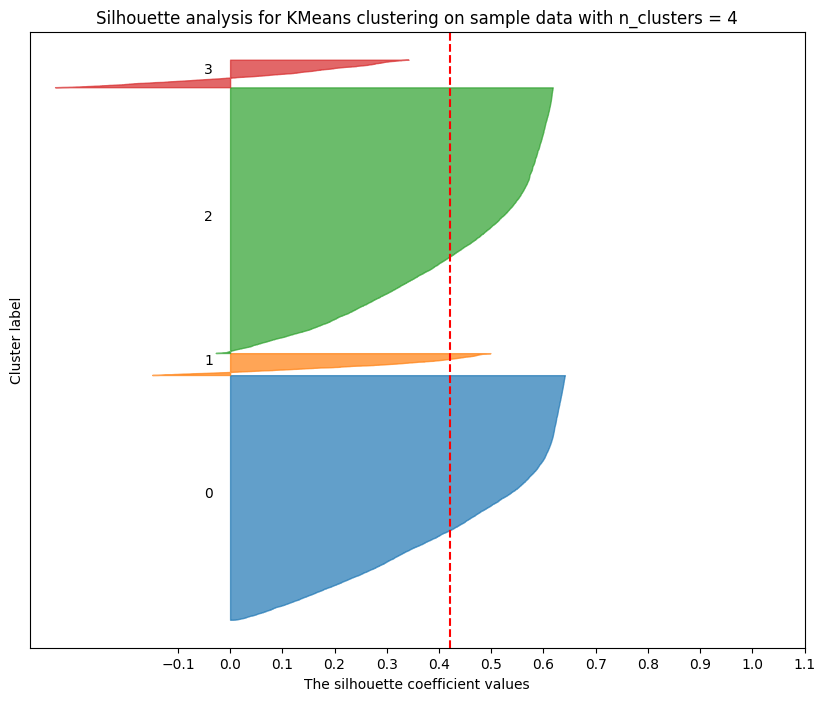

Visualisation du clustering (2D)...


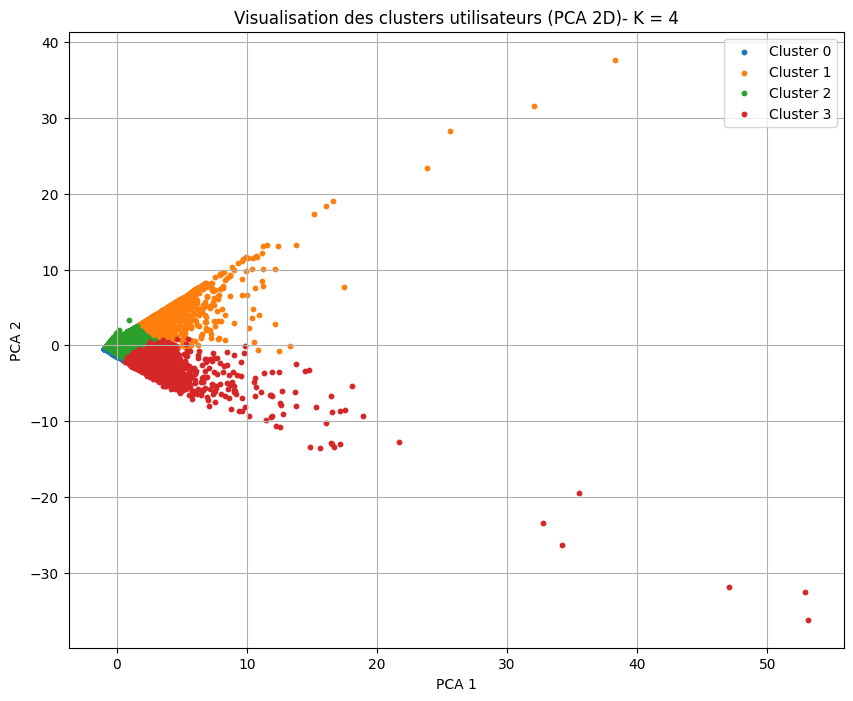

Visualisation du clustering (3D)...


In [26]:
N_CLUSTERS = 4

df_kmeans = kmeans_fit_and_plot_per_cluster(N_CLUSTERS, X_final, user_events_df)

In [ ]:
df_kmeans["segment"].value_counts()

segment
0    14069
1    13342
2     2556
3       33
Name: count, dtype: int64

Number of individuals per cluster:
segment
0    14069
1    13342
2     2556
3       33
Name: count, dtype: int64


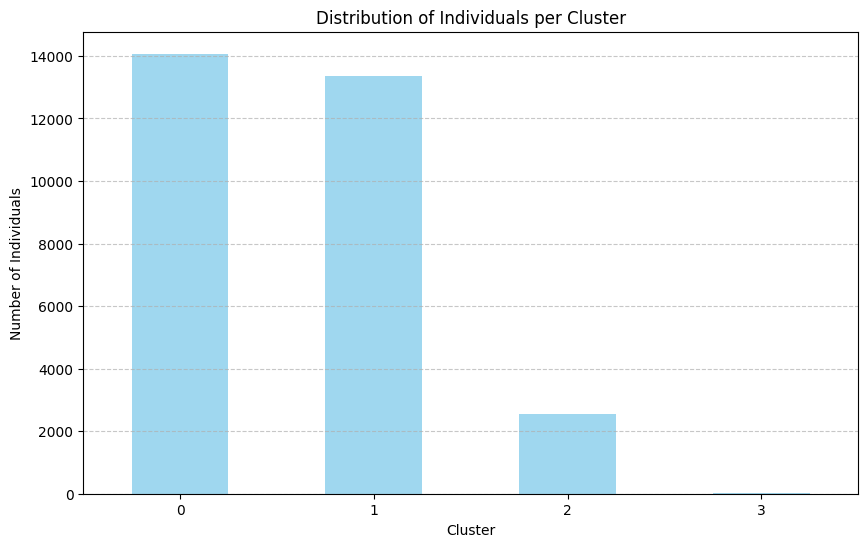


Descriptive statistics for Cluster 0:
       total_events   total_views  total_purchases   total_spent  \
count  14069.000000  14069.000000     14069.000000  14069.000000   
mean      36.650366     34.881868         0.320989     53.042270   
min       10.000000      1.000000         0.000000      0.000000   
25%       16.000000     15.000000         0.000000      0.000000   
50%       26.000000     24.000000         0.000000      0.000000   
75%       48.000000     45.000000         0.000000      0.000000   
max      167.000000    157.000000        12.000000   2119.600000   
std       29.239502     28.359443         0.807028    166.409811   

         avg_basket             last_event_time  segment  
count  14069.000000                       14069  14069.0  
mean      32.799524  2019-11-21 22:58:19.499680      0.0  
min        0.000000         2019-11-01 02:11:32      0.0  
25%        0.000000         2019-11-17 03:31:33      0.0  
50%        0.000000         2019-11-23 02:23:23      

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




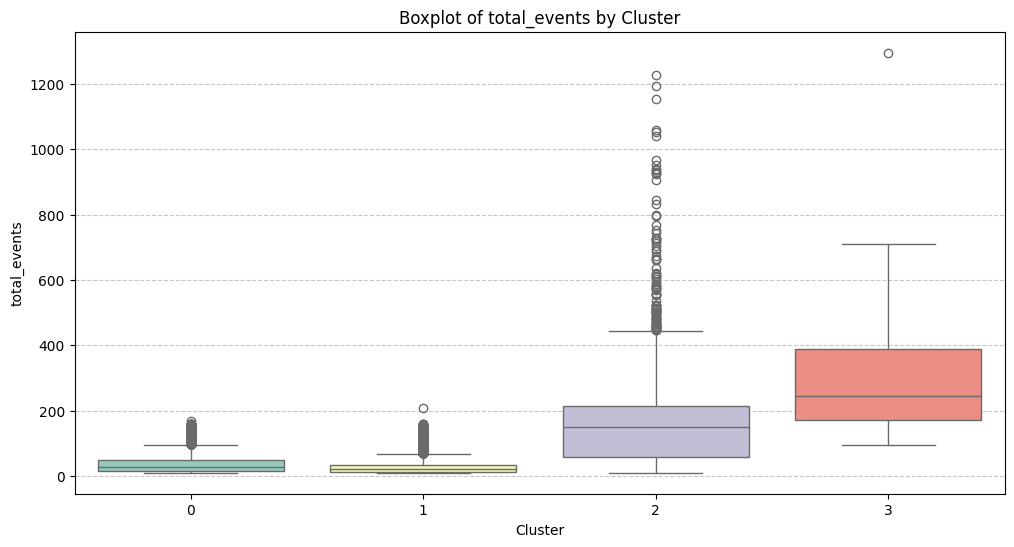

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




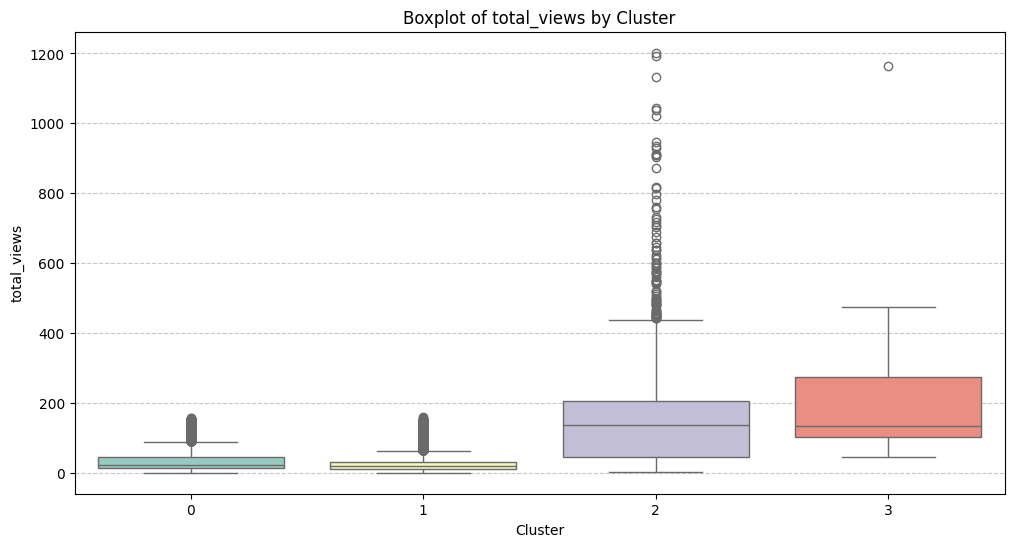

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




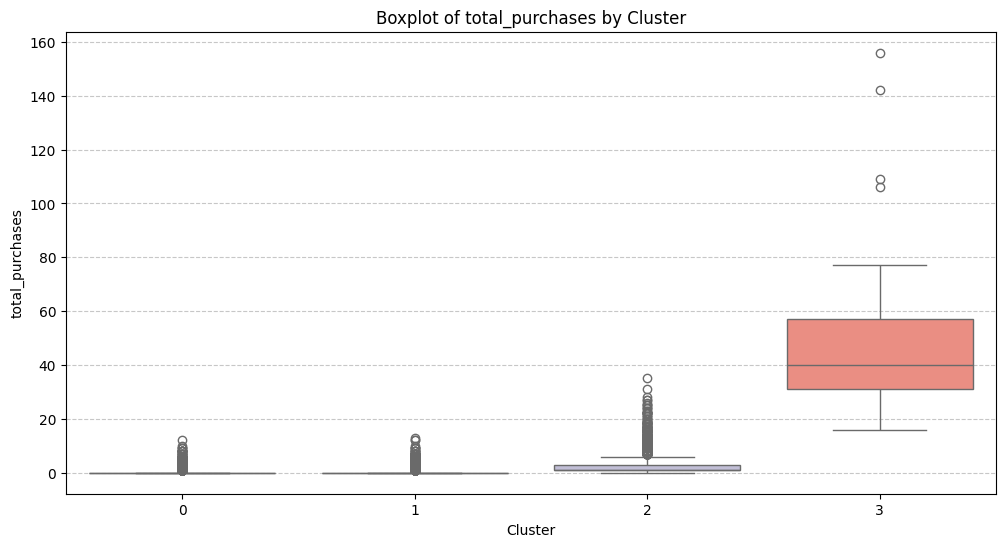

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




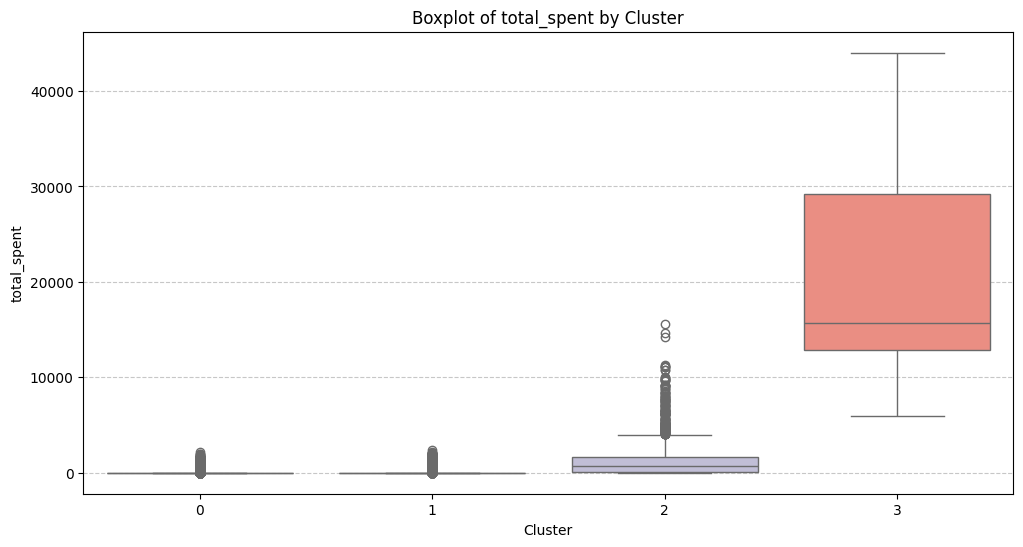

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




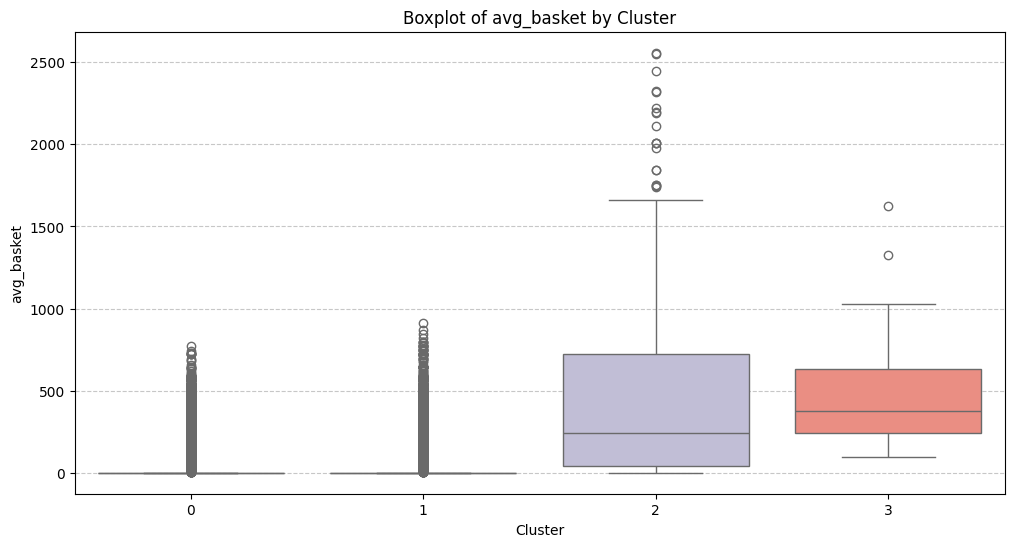

{0:        total_events   total_views  total_purchases   total_spent  \
 count  14069.000000  14069.000000     14069.000000  14069.000000   
 mean      36.650366     34.881868         0.320989     53.042270   
 min       10.000000      1.000000         0.000000      0.000000   
 25%       16.000000     15.000000         0.000000      0.000000   
 50%       26.000000     24.000000         0.000000      0.000000   
 75%       48.000000     45.000000         0.000000      0.000000   
 max      167.000000    157.000000        12.000000   2119.600000   
 std       29.239502     28.359443         0.807028    166.409811   
 
          avg_basket             last_event_time  segment  
 count  14069.000000                       14069  14069.0  
 mean      32.799524  2019-11-21 22:58:19.499680      0.0  
 min        0.000000         2019-11-01 02:11:32      0.0  
 25%        0.000000         2019-11-17 03:31:33      0.0  
 50%        0.000000         2019-11-23 02:23:23      0.0  
 75%        0.

In [ ]:
plot_cluster_stats(df_kmeans, segment_column="segment")

### Gaussian Mixture Model (GMM) Clustering

Silhouette Analysis for GMM...
For n_components = 4, the average silhouette_score is: 0.07456871316869747
BIC: -786990.71, AIC: -787913.00
Silhouette score for Cluster 0: -0.14351549756786297
Silhouette score for Cluster 1: 0.29653099828068974
Silhouette score for Cluster 2: -0.06125142105877192
Silhouette score for Cluster 3: -0.24973845907443185


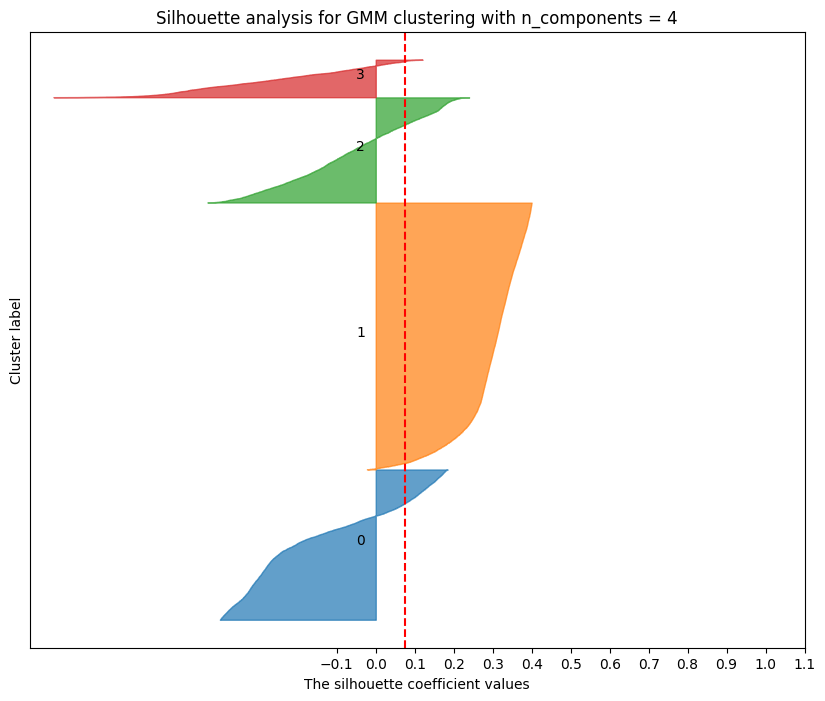

Visualisation du clustering (2D)...


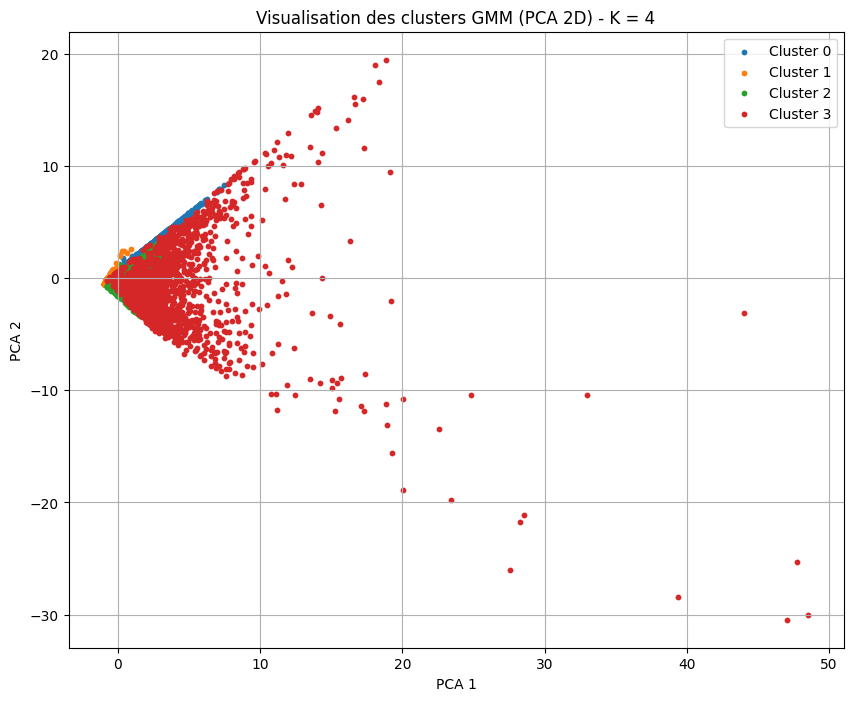

Visualisation du clustering (3D)...


In [ ]:
# GMM clustering with 4 components
N_COMPONENTS = 4

df_gmm = gmm_fit_and_plot_per_cluster(N_COMPONENTS, X_final, user_events_df, covariance_type='full')

In [ ]:
df_gmm["segment"].value_counts()

segment
1    14300
0     8055
2     5634
3     2011
Name: count, dtype: int64

Number of individuals per cluster:
segment
0     8055
1    14300
2     5634
3     2011
Name: count, dtype: int64


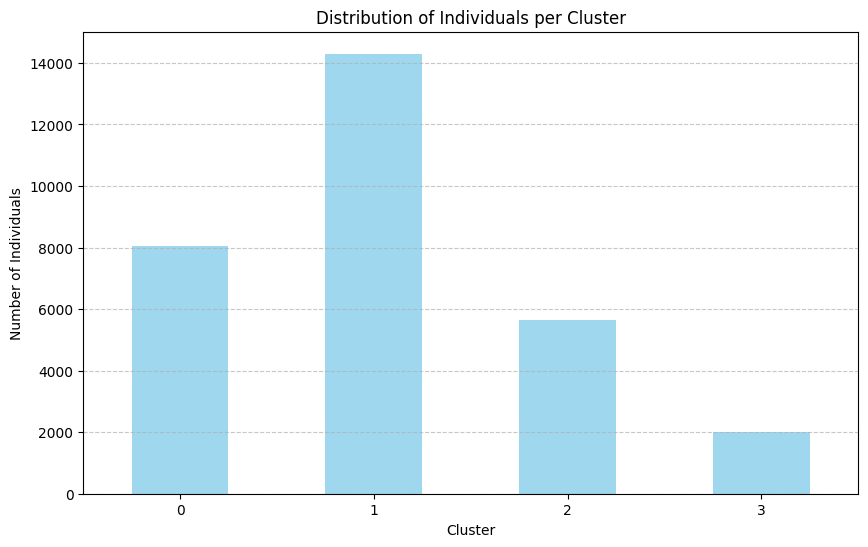


Descriptive statistics for Cluster 0:
       total_events  total_views  total_purchases  total_spent  avg_basket  \
count   8055.000000  8055.000000           8055.0       8055.0      8055.0   
mean      60.380012    57.951210              0.0          0.0         0.0   
min       10.000000     2.000000              0.0          0.0         0.0   
25%       20.000000    18.000000              0.0          0.0         0.0   
50%       40.000000    37.000000              0.0          0.0         0.0   
75%       79.000000    77.000000              0.0          0.0         0.0   
max      522.000000   518.000000              0.0          0.0         0.0   
std       59.658067    59.413947              0.0          0.0         0.0   

                  last_event_time  segment  
count                        8055   8055.0  
mean   2019-11-22 20:54:41.891371      0.0  
min           2019-11-01 04:51:09      0.0  
25%    2019-11-17 08:06:06.500000      0.0  
50%           2019-11-23 17:59:24

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




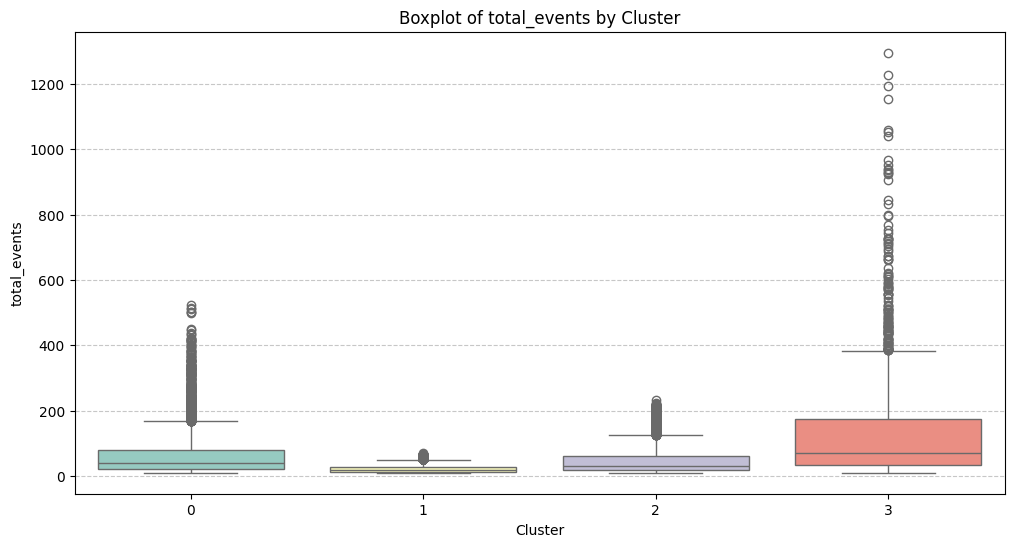

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




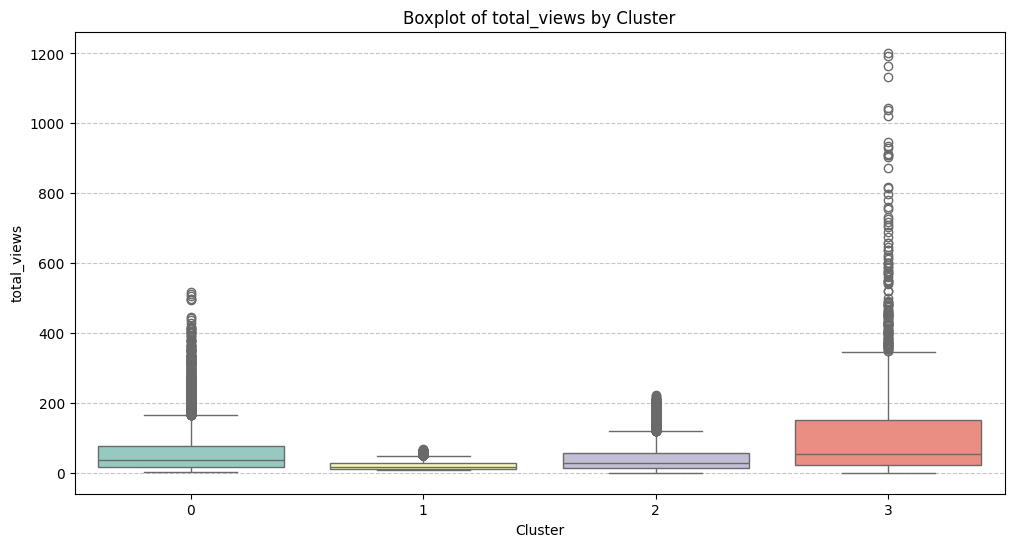

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




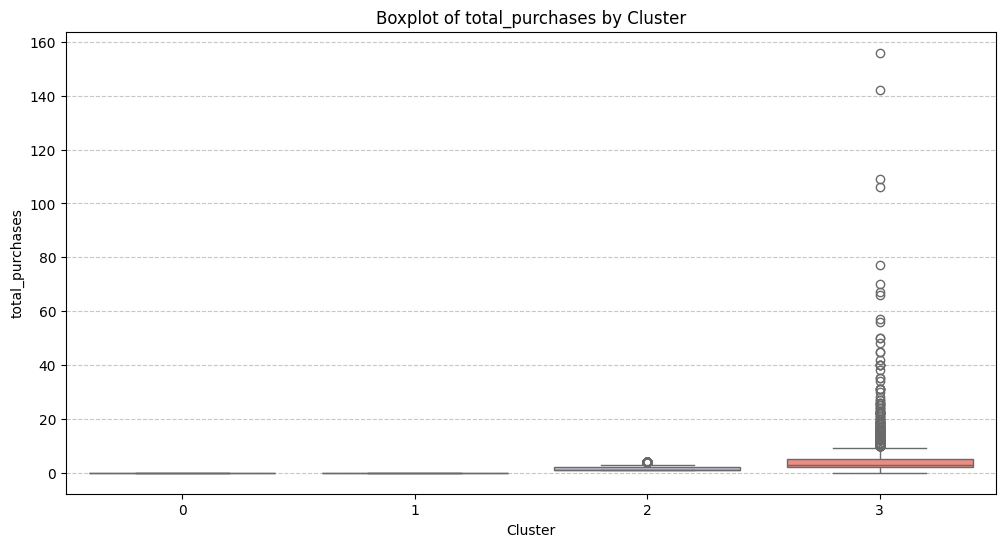

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




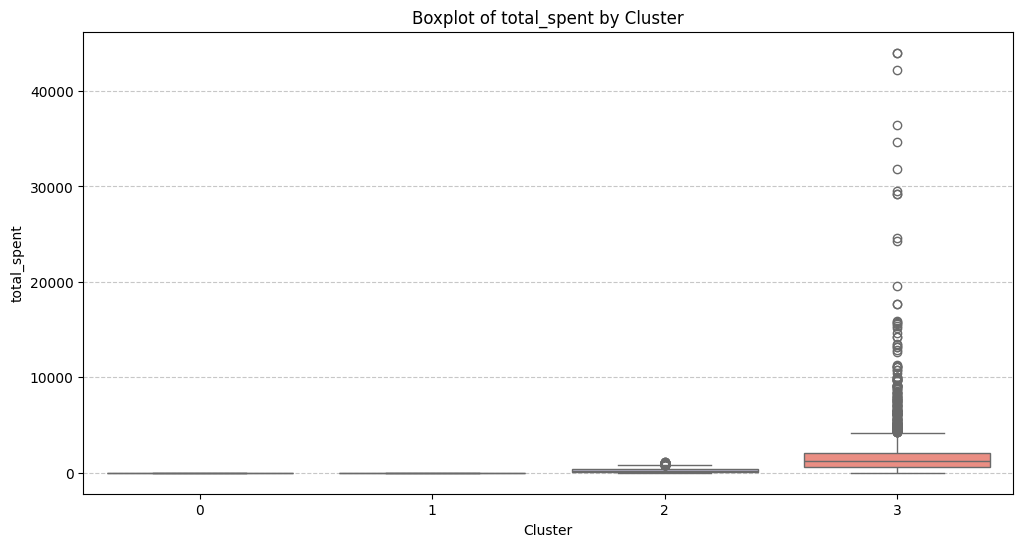

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




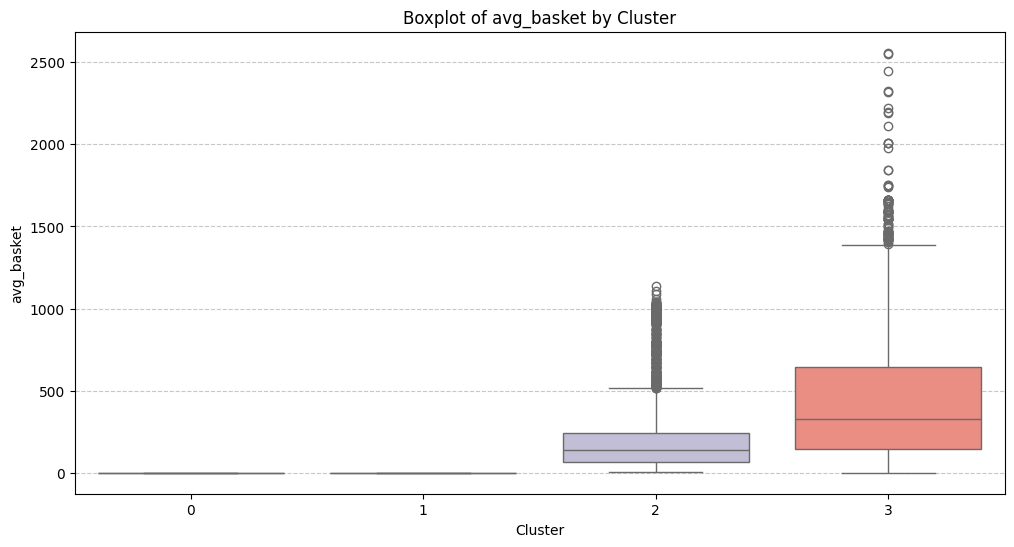

{0:        total_events  total_views  total_purchases  total_spent  avg_basket  \
 count   8055.000000  8055.000000           8055.0       8055.0      8055.0   
 mean      60.380012    57.951210              0.0          0.0         0.0   
 min       10.000000     2.000000              0.0          0.0         0.0   
 25%       20.000000    18.000000              0.0          0.0         0.0   
 50%       40.000000    37.000000              0.0          0.0         0.0   
 75%       79.000000    77.000000              0.0          0.0         0.0   
 max      522.000000   518.000000              0.0          0.0         0.0   
 std       59.658067    59.413947              0.0          0.0         0.0   
 
                   last_event_time  segment  
 count                        8055   8055.0  
 mean   2019-11-22 20:54:41.891371      0.0  
 min           2019-11-01 04:51:09      0.0  
 25%    2019-11-17 08:06:06.500000      0.0  
 50%           2019-11-23 17:59:24      0.0  
 75%    

In [ ]:
plot_cluster_stats(df_gmm, segment_column="segment")

### DBSCAN Clustering

DBSCAN Results:
Number of clusters found: 10
Number of noise points: 1587 (5.29%)
Average silhouette_score (excluding noise): 0.4524375071626451
Silhouette score for Cluster 0 (size: 28293): 0.4515434603582985
Silhouette score for Cluster 1 (size: 19): 0.5422324834153666
Silhouette score for Cluster 2 (size: 11): 0.5002028307146027
Silhouette score for Cluster 3 (size: 18): 0.7377184796382168
Silhouette score for Cluster 4 (size: 10): 0.5522516061652033
Silhouette score for Cluster 5 (size: 16): 0.49435962524068483
Silhouette score for Cluster 6 (size: 14): 0.9117501896281326
Silhouette score for Cluster 7 (size: 15): 0.8706798096885926
Silhouette score for Cluster 8 (size: 7): 0.5715656606088881
Silhouette score for Cluster 9 (size: 10): 0.7246256648765451


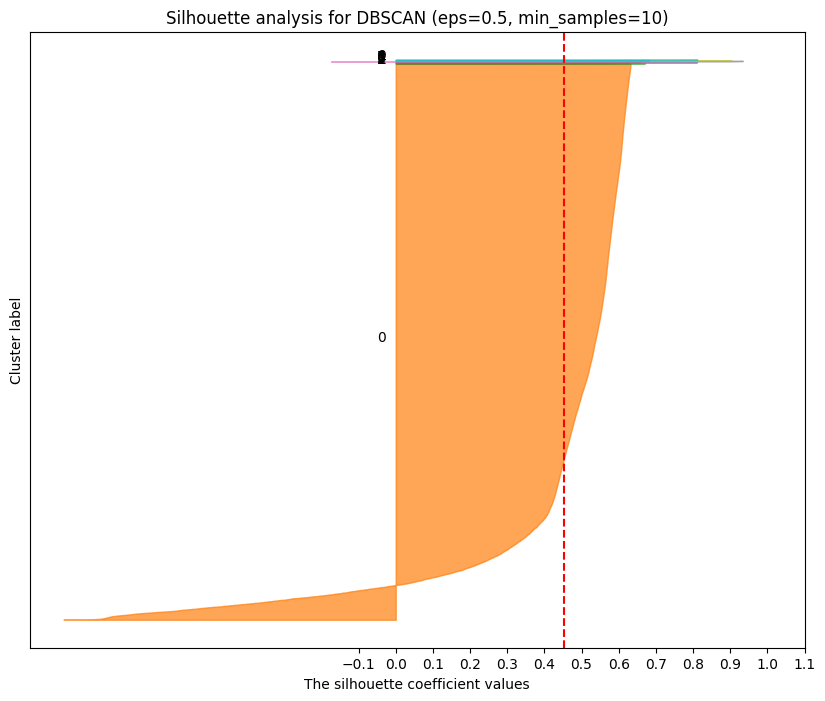

Visualisation du clustering (2D)...


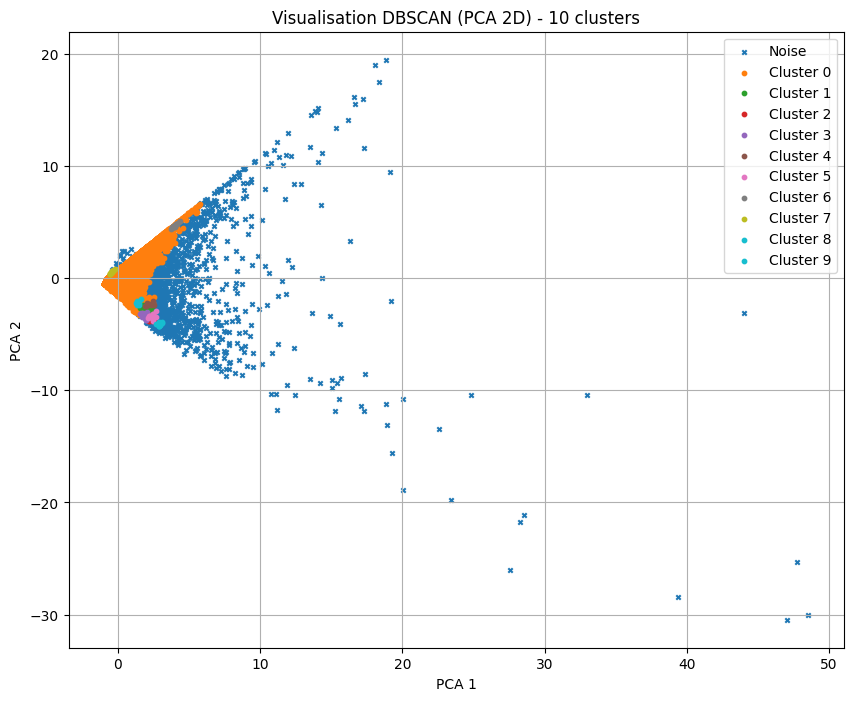

Visualisation du clustering (3D)...


In [ ]:
# DBSCAN clustering
# eps: Maximum distance between two samples to be in same neighborhood
# min_samples: Minimum samples in a neighborhood for a core point
EPS = 0.5  # Adjust based on your scaled data
MIN_SAMPLES = 10

df_dbscan = dbscan_fit_and_plot(EPS, MIN_SAMPLES, X_final, user_events_df)

In [ ]:
df_dbscan["segment"].value_counts()

segment
 0    28293
-1     1587
 1       19
 3       18
 5       16
 7       15
 6       14
 2       11
 4       10
 9       10
 8        7
Name: count, dtype: int64

Number of individuals per cluster:
segment
-1     1587
 0    28293
 1       19
 2       11
 3       18
 4       10
 5       16
 6       14
 7       15
 8        7
 9       10
Name: count, dtype: int64


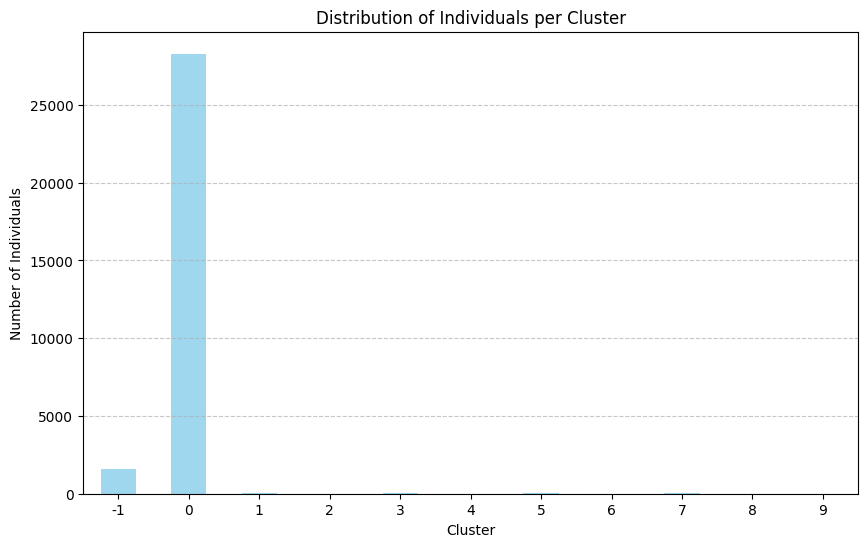


Descriptive statistics for Cluster -1:
       total_events  total_views  total_purchases   total_spent   avg_basket  \
count   1587.000000  1587.000000      1587.000000   1587.000000  1587.000000   
mean     161.494014   144.179584         5.613106   2197.728639   480.599878   
min       10.000000     4.000000         0.000000      0.000000     0.000000   
25%       50.500000    36.000000         2.000000    552.005000   153.108333   
50%      102.000000    84.000000         3.000000   1341.010000   347.470000   
75%      211.000000   190.500000         6.000000   2386.100000   700.030833   
max     1295.000000  1202.000000       156.000000  44018.650000  2557.590000   
std      168.900791   165.057283         9.340972   3590.397478   435.038669   

                  last_event_time  segment  
count                        1587   1587.0  
mean   2019-11-25 01:27:42.313799     -1.0  
min           2019-11-01 02:29:10     -1.0  
25%    2019-11-21 05:10:43.500000     -1.0  
50%           

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




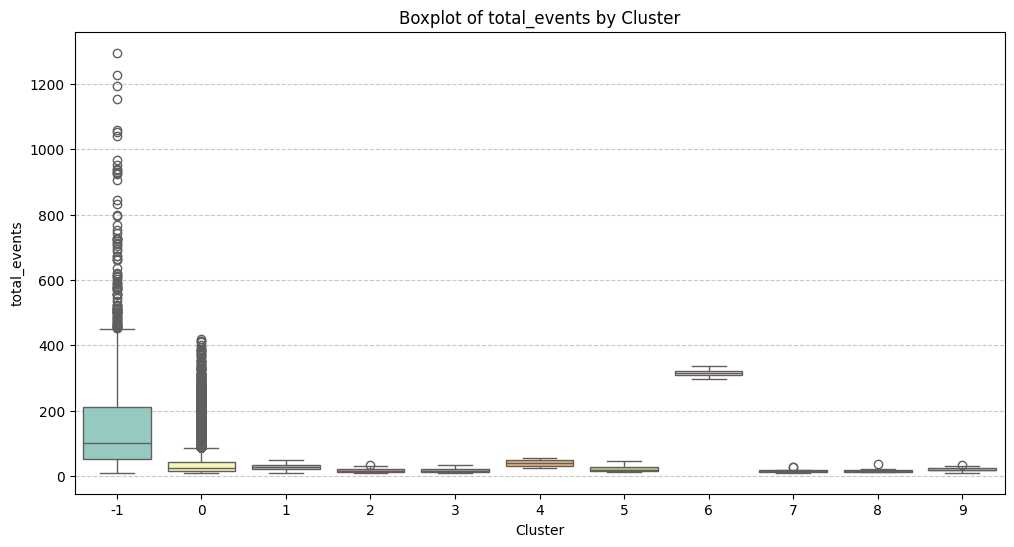

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




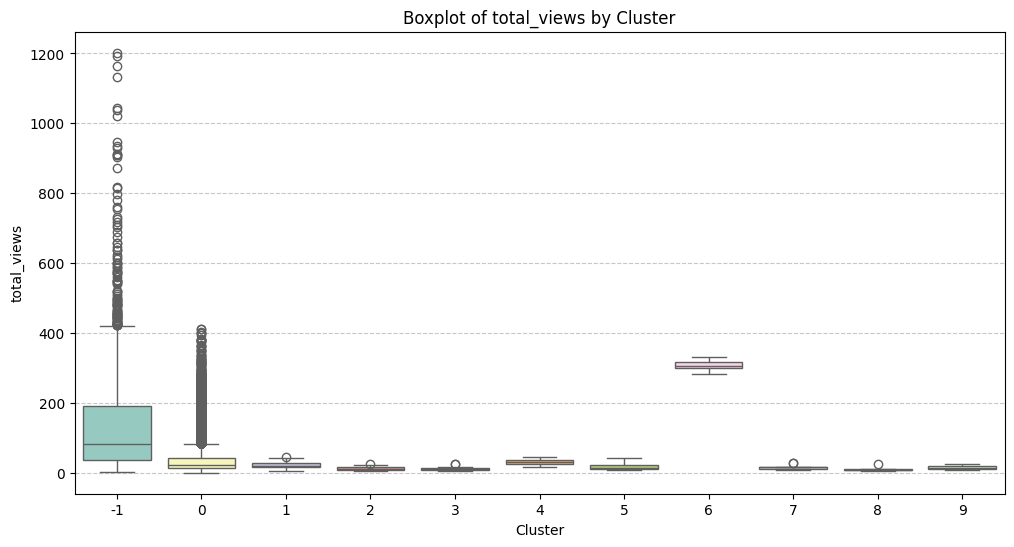

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




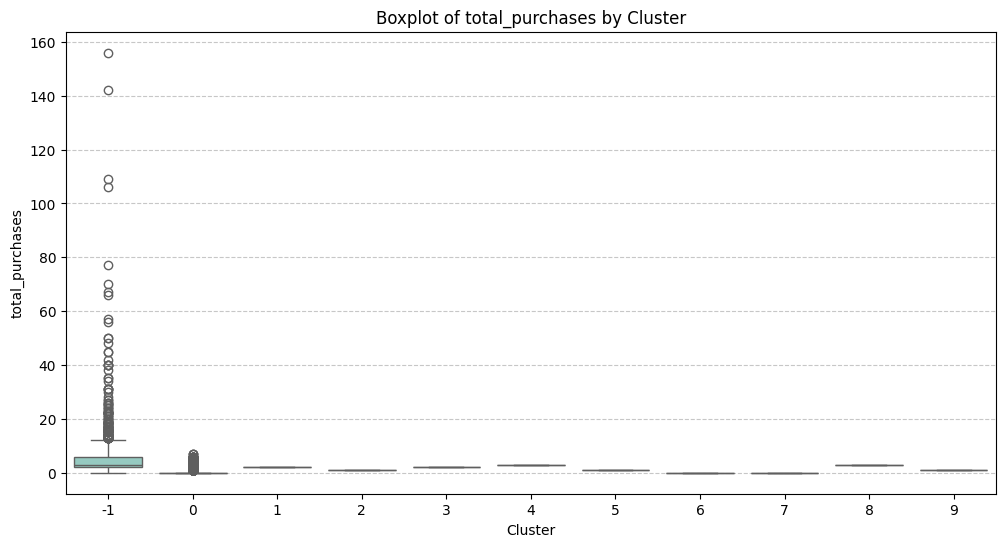

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




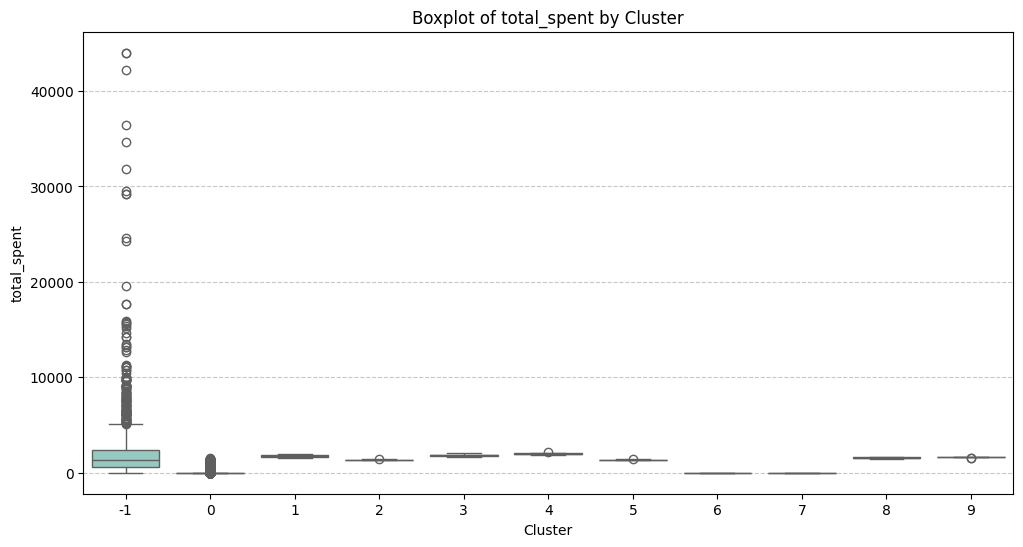

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




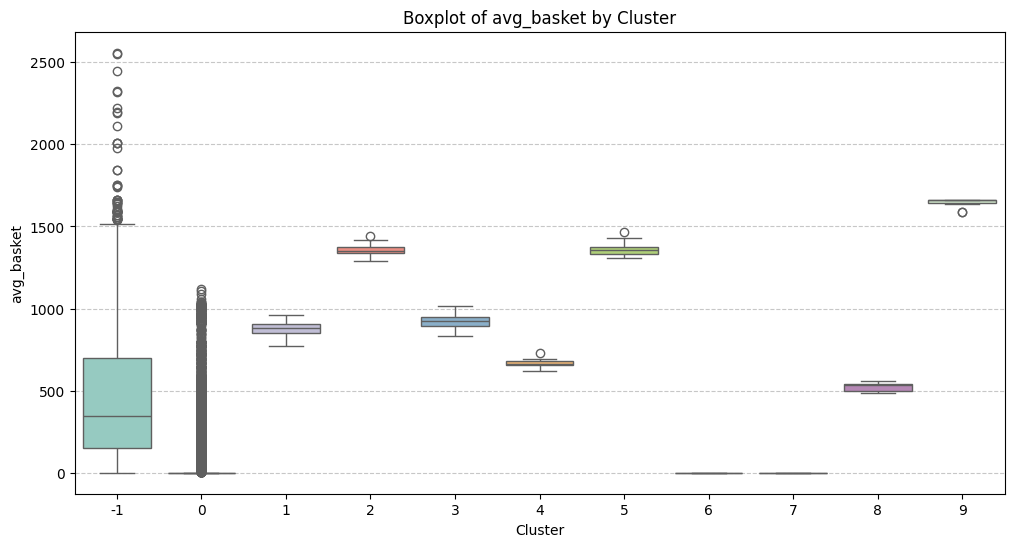

{-1:        total_events  total_views  total_purchases   total_spent   avg_basket  \
 count   1587.000000  1587.000000      1587.000000   1587.000000  1587.000000   
 mean     161.494014   144.179584         5.613106   2197.728639   480.599878   
 min       10.000000     4.000000         0.000000      0.000000     0.000000   
 25%       50.500000    36.000000         2.000000    552.005000   153.108333   
 50%      102.000000    84.000000         3.000000   1341.010000   347.470000   
 75%      211.000000   190.500000         6.000000   2386.100000   700.030833   
 max     1295.000000  1202.000000       156.000000  44018.650000  2557.590000   
 std      168.900791   165.057283         9.340972   3590.397478   435.038669   
 
                   last_event_time  segment  
 count                        1587   1587.0  
 mean   2019-11-25 01:27:42.313799     -1.0  
 min           2019-11-01 02:29:10     -1.0  
 25%    2019-11-21 05:10:43.500000     -1.0  
 50%           2019-11-27 10:40:42 

In [ ]:
# Note: DBSCAN may have noise points labeled as -1
plot_cluster_stats(df_dbscan, segment_column="segment")

### BIRCH Clustering

BIRCH Results:
Number of clusters found: 4
Silhouette Analysis for BIRCH...
For n_clusters = 4, the average silhouette_score is: 0.7449071473375881
Silhouette score for Cluster 0 (size: 29): 0.05047269256306642
Silhouette score for Cluster 1 (size: 29406): 0.7520771330970439
Silhouette score for Cluster 2 (size: 368): 0.48599546033888325
Silhouette score for Cluster 3 (size: 197): 0.26052896846158174


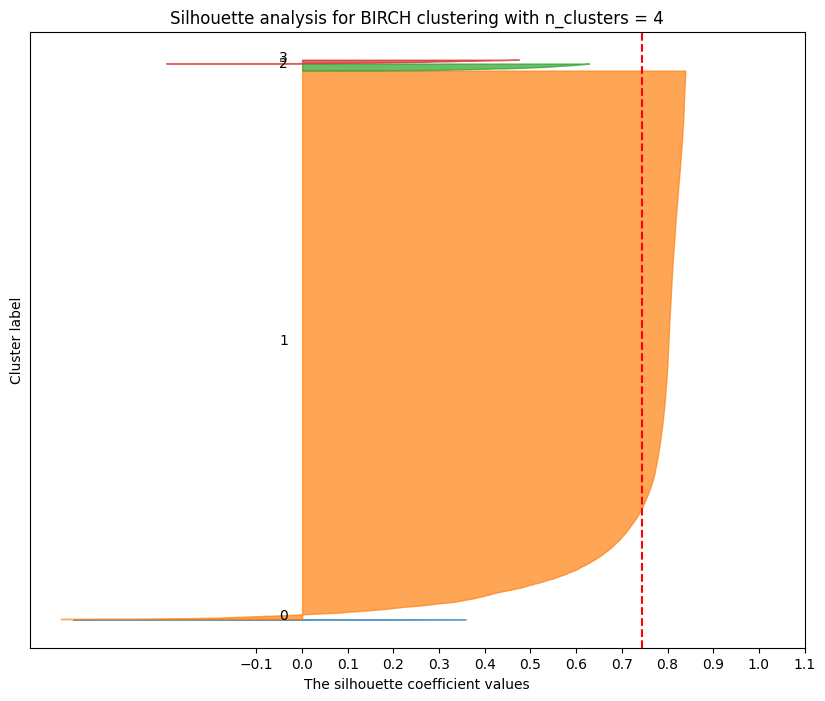

Visualisation du clustering (2D)...


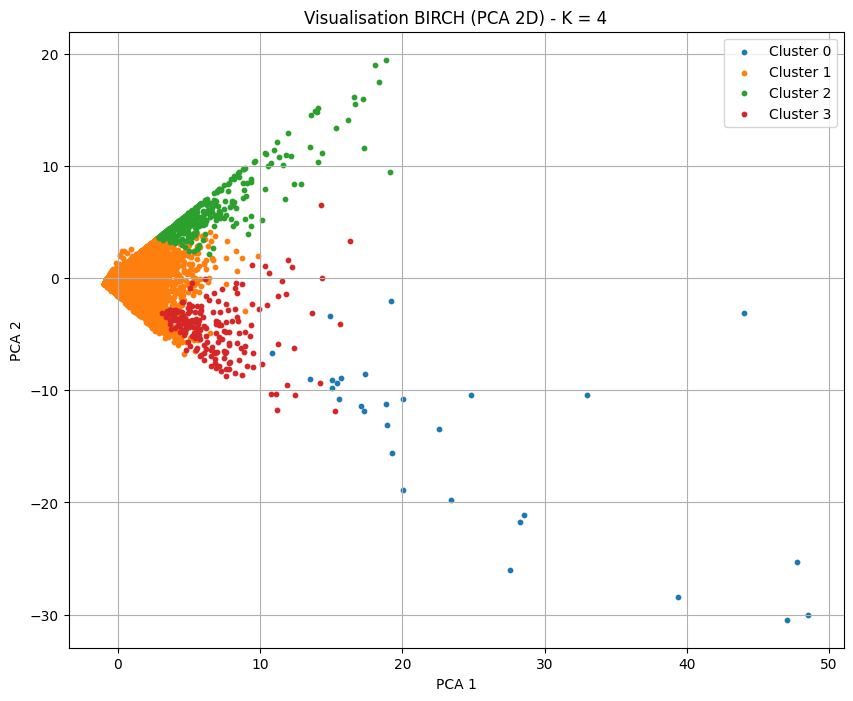

Visualisation du clustering (3D)...


In [ ]:
# BIRCH clustering
N_CLUSTERS_BIRCH = 4
THRESHOLD = 0.5  # Maximum radius of subcluster
BRANCHING_FACTOR = 50  # Maximum number of CF subclusters in each node

df_birch = birch_fit_and_plot_per_cluster(N_CLUSTERS_BIRCH, X_final, user_events_df, 
                                          threshold=THRESHOLD, branching_factor=BRANCHING_FACTOR)

In [ ]:
df_birch["segment"].value_counts()

segment
1    29406
2      368
3      197
0       29
Name: count, dtype: int64

Number of individuals per cluster:
segment
0       29
1    29406
2      368
3      197
Name: count, dtype: int64


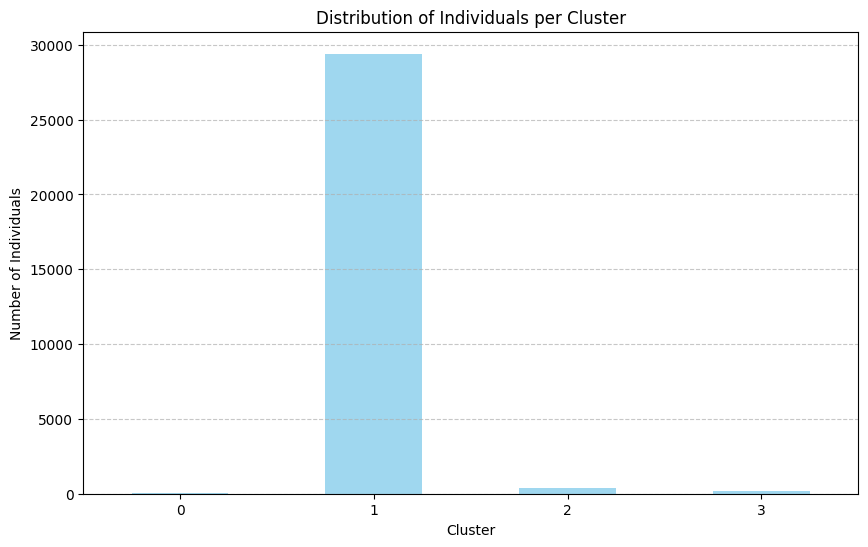


Descriptive statistics for Cluster 0:
       total_events  total_views  total_purchases   total_spent   avg_basket  \
count     29.000000    29.000000        29.000000     29.000000    29.000000   
mean     343.137931   212.068966        56.137931  20367.658276   450.663937   
min       95.000000    46.000000        22.000000   5932.980000    98.442547   
25%      211.000000   105.000000        35.000000  12649.160000   191.915429   
50%      247.000000   136.000000        45.000000  15347.090000   332.872632   
75%      389.000000   275.000000        66.000000  29243.440000   518.066667   
max     1295.000000  1163.000000       156.000000  44018.650000  1624.120385   
std      249.703642   212.650943        33.184252  11796.261004   367.934275   

                  last_event_time  segment  
count                          29     29.0  
mean   2019-11-27 23:44:22.724138      0.0  
min           2019-11-17 10:42:17      0.0  
25%           2019-11-27 05:11:42      0.0  
50%           2

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




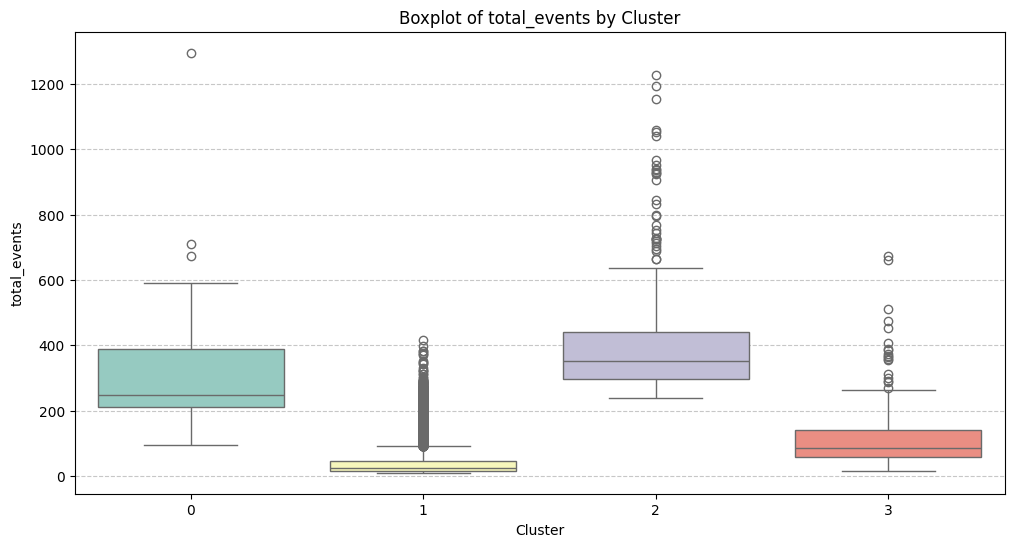

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




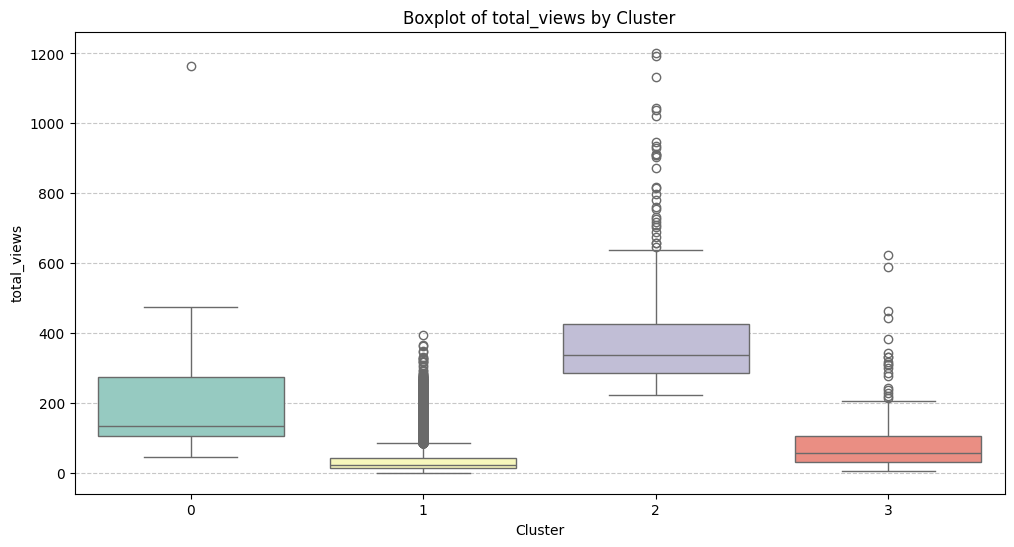

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




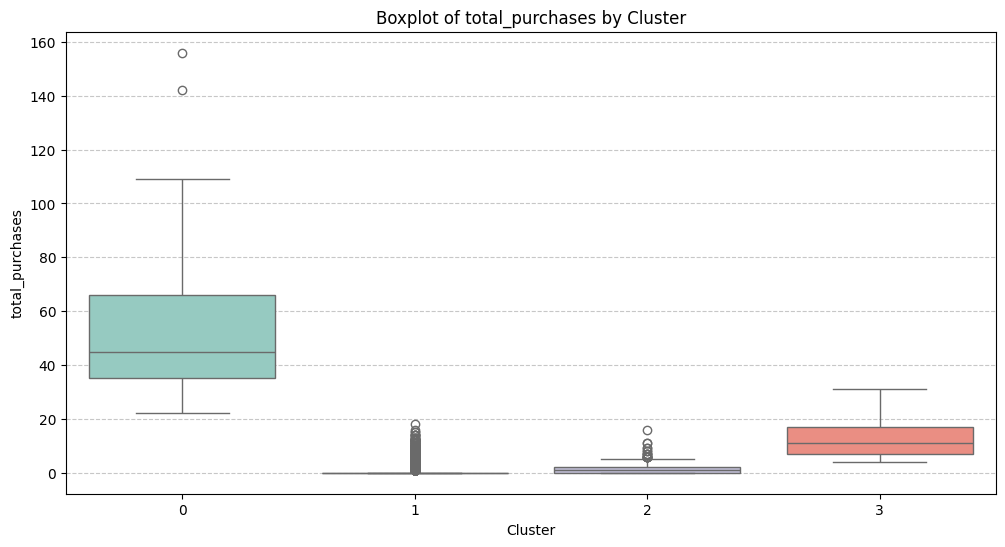

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




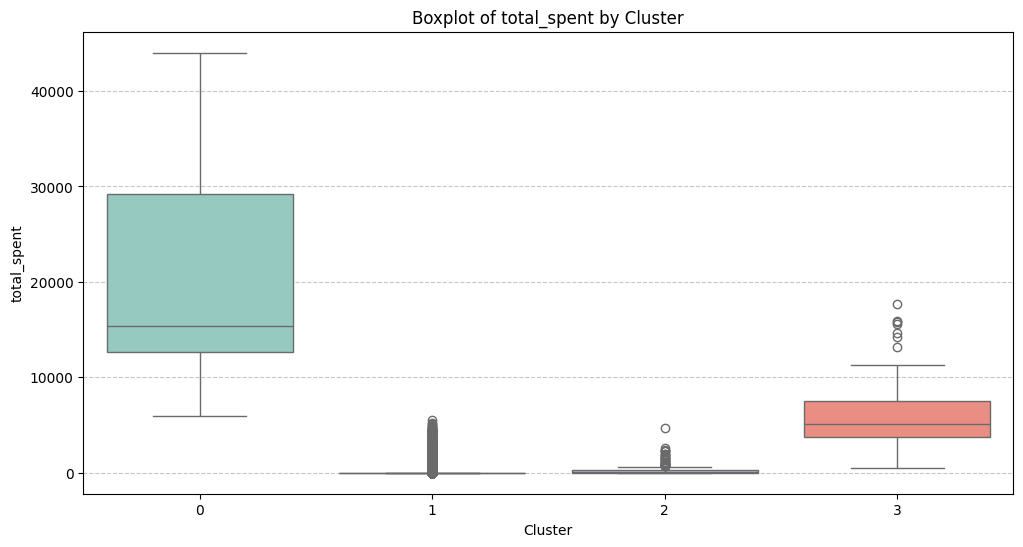

/tmp/ipykernel_34803/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




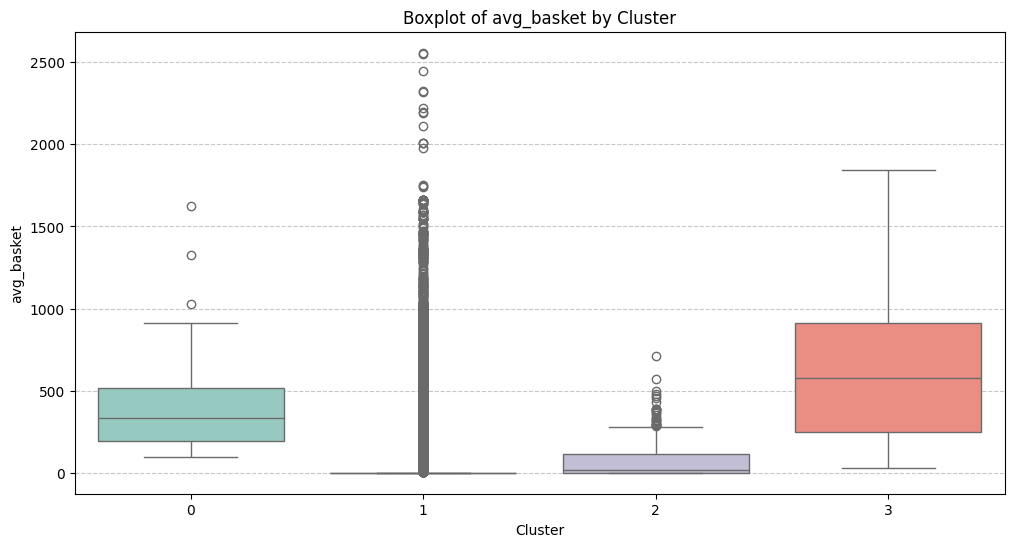

{0:        total_events  total_views  total_purchases   total_spent   avg_basket  \
 count     29.000000    29.000000        29.000000     29.000000    29.000000   
 mean     343.137931   212.068966        56.137931  20367.658276   450.663937   
 min       95.000000    46.000000        22.000000   5932.980000    98.442547   
 25%      211.000000   105.000000        35.000000  12649.160000   191.915429   
 50%      247.000000   136.000000        45.000000  15347.090000   332.872632   
 75%      389.000000   275.000000        66.000000  29243.440000   518.066667   
 max     1295.000000  1163.000000       156.000000  44018.650000  1624.120385   
 std      249.703642   212.650943        33.184252  11796.261004   367.934275   
 
                   last_event_time  segment  
 count                          29     29.0  
 mean   2019-11-27 23:44:22.724138      0.0  
 min           2019-11-17 10:42:17      0.0  
 25%           2019-11-27 05:11:42      0.0  
 50%           2019-11-29 10:49:30  

In [ ]:
plot_cluster_stats(df_birch, segment_column="segment")

In [ ]:
stop

NameError: name 'stop' is not defined

### Sauvegarde du DataFrame en Table DuckDB


#### Sauvegarde KMeans

In [ ]:
con.execute(f"DROP TABLE IF EXISTS {TABLE_SEGMENTS}_kmeans")

con.execute(f"""
CREATE TABLE {TABLE_SEGMENTS}_kmeans AS
SELECT * FROM df_kmeans
""")

print("Clustering KMeans sauvegardé avec succès !")


Clustering sauvegardé avec succès !


#### Sauvegarde GMM

In [ ]:
con.execute(f"DROP TABLE IF EXISTS {TABLE_SEGMENTS}_gmm")

con.execute(f"""
CREATE TABLE {TABLE_SEGMENTS}_gmm AS
SELECT * FROM df_gmm
""")

print("Clustering GMM sauvegardé avec succès !")

#### Sauvegarde DBSCAN

In [ ]:
con.execute(f"DROP TABLE IF EXISTS {TABLE_SEGMENTS}_dbscan")

con.execute(f"""
CREATE TABLE {TABLE_SEGMENTS}_dbscan AS
SELECT * FROM df_dbscan
""")

print("Clustering DBSCAN sauvegardé avec succès !")

#### Sauvegarde BIRCH

In [ ]:
con.execute(f"DROP TABLE IF EXISTS {TABLE_SEGMENTS}_birch")

con.execute(f"""
CREATE TABLE {TABLE_SEGMENTS}_birch AS
SELECT * FROM df_birch
""")

print("Clustering BIRCH sauvegardé avec succès !")

#### Vérification des tables sauvegardées

In [ ]:
# Vérification KMeans
print("=== KMeans ===")
user_segments_kmeans = con.sql(f"""
    SELECT * FROM {TABLE_SEGMENTS}_kmeans LIMIT 5
""")
user_segments_kmeans.show()

# Vérification GMM
print("\n=== GMM ===")
user_segments_gmm = con.sql(f"""
    SELECT * FROM {TABLE_SEGMENTS}_gmm LIMIT 5
""")
user_segments_gmm.show()

# Vérification DBSCAN
print("\n=== DBSCAN ===")
user_segments_dbscan = con.sql(f"""
    SELECT * FROM {TABLE_SEGMENTS}_dbscan LIMIT 5
""")
user_segments_dbscan.show()

# Vérification BIRCH
print("\n=== BIRCH ===")
user_segments_birch = con.sql(f"""
    SELECT * FROM {TABLE_SEGMENTS}_birch LIMIT 5
""")
user_segments_birch.show()

┌───────────┬──────────────┬─────────────┬─────────────────┬───────────────────┬────────────────────┬─────────────────────┬─────────┐
│  user_id  │ total_events │ total_views │ total_purchases │    total_spent    │     avg_basket     │   last_event_time   │ segment │
│  varchar  │    int64     │   double    │     double      │      double       │       double       │      timestamp      │  int32  │
├───────────┼──────────────┼─────────────┼─────────────────┼───────────────────┼────────────────────┼─────────────────────┼─────────┤
│ 524323265 │           15 │        14.0 │             0.0 │               0.0 │                0.0 │ 2019-11-25 10:46:39 │       1 │
│ 514466368 │           35 │        28.0 │             2.0 │             83.82 │              41.91 │ 2019-11-22 04:03:03 │       1 │
│ 516712520 │           20 │        19.0 │             0.0 │               0.0 │                0.0 │ 2019-11-16 08:13:12 │       1 │
│ 572665715 │           42 │        39.0 │             1.0 │  

In [ ]:
# Distribution des segments pour chaque modèle
print("=== Distribution KMeans ===")
print(user_segments_kmeans.df()["segment"].value_counts())

print("\n=== Distribution GMM ===")
print(user_segments_gmm.df()["segment"].value_counts())

print("\n=== Distribution DBSCAN ===")
print(user_segments_dbscan.df()["segment"].value_counts())

print("\n=== Distribution BIRCH ===")
print(user_segments_birch.df()["segment"].value_counts())

segment
1    269612
0     29561
3       826
2         1
Name: count, dtype: int64

### Comparaison des Algorithmes de Clustering

In [ ]:
# Create a comparison summary
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Calculate metrics for each clustering result
results = []

# KMeans
kmeans_silhouette = silhouette_score(X_final, df_kmeans["segment"])
kmeans_db = davies_bouldin_score(X_final, df_kmeans["segment"])
kmeans_ch = calinski_harabasz_score(X_final, df_kmeans["segment"])
results.append({
    'Algorithm': 'KMeans',
    'N_Clusters': df_kmeans["segment"].nunique(),
    'Silhouette': kmeans_silhouette,
    'Davies-Bouldin': kmeans_db,
    'Calinski-Harabasz': kmeans_ch
})

# GMM
gmm_silhouette = silhouette_score(X_final, df_gmm["segment"])
gmm_db = davies_bouldin_score(X_final, df_gmm["segment"])
gmm_ch = calinski_harabasz_score(X_final, df_gmm["segment"])
results.append({
    'Algorithm': 'GMM',
    'N_Clusters': df_gmm["segment"].nunique(),
    'Silhouette': gmm_silhouette,
    'Davies-Bouldin': gmm_db,
    'Calinski-Harabasz': gmm_ch
})

# DBSCAN (exclude noise points if present)
dbscan_no_noise = df_dbscan[df_dbscan["segment"] != -1]
if len(dbscan_no_noise) > 0 and dbscan_no_noise["segment"].nunique() > 1:
    X_dbscan_no_noise = X_final[df_dbscan["segment"].values != -1]
    dbscan_silhouette = silhouette_score(X_dbscan_no_noise, dbscan_no_noise["segment"])
    dbscan_db = davies_bouldin_score(X_dbscan_no_noise, dbscan_no_noise["segment"])
    dbscan_ch = calinski_harabasz_score(X_dbscan_no_noise, dbscan_no_noise["segment"])
    n_noise = (df_dbscan["segment"] == -1).sum()
    results.append({
        'Algorithm': f'DBSCAN ({n_noise} noise)',
        'N_Clusters': dbscan_no_noise["segment"].nunique(),
        'Silhouette': dbscan_silhouette,
        'Davies-Bouldin': dbscan_db,
        'Calinski-Harabasz': dbscan_ch
    })
else:
    results.append({
        'Algorithm': 'DBSCAN',
        'N_Clusters': df_dbscan["segment"].nunique(),
        'Silhouette': None,
        'Davies-Bouldin': None,
        'Calinski-Harabasz': None
    })

# BIRCH
birch_silhouette = silhouette_score(X_final, df_birch["segment"])
birch_db = davies_bouldin_score(X_final, df_birch["segment"])
birch_ch = calinski_harabasz_score(X_final, df_birch["segment"])
results.append({
    'Algorithm': 'BIRCH',
    'N_Clusters': df_birch["segment"].nunique(),
    'Silhouette': birch_silhouette,
    'Davies-Bouldin': birch_db,
    'Calinski-Harabasz': birch_ch
})

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)

print("="*80)
print("COMPARAISON DES ALGORITHMES DE CLUSTERING")
print("="*80)
print("\nMétriques de performance:")
print("- Silhouette Score: Plus proche de 1 = meilleur (range: -1 to 1)")
print("- Davies-Bouldin Index: Plus petit = meilleur (0 = meilleur)")
print("- Calinski-Harabasz Score: Plus grand = meilleur")
print("\n")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score
ax1 = axes[0]
comparison_df_valid = comparison_df[comparison_df['Silhouette'].notna()]
ax1.barh(comparison_df_valid['Algorithm'], comparison_df_valid['Silhouette'], color='skyblue')
ax1.set_xlabel('Silhouette Score')
ax1.set_title('Silhouette Score (Higher is Better)')
ax1.grid(axis='x', alpha=0.3)

# Davies-Bouldin Index
ax2 = axes[1]
comparison_df_valid = comparison_df[comparison_df['Davies-Bouldin'].notna()]
ax2.barh(comparison_df_valid['Algorithm'], comparison_df_valid['Davies-Bouldin'], color='lightcoral')
ax2.set_xlabel('Davies-Bouldin Index')
ax2.set_title('Davies-Bouldin Index (Lower is Better)')
ax2.grid(axis='x', alpha=0.3)

# Calinski-Harabasz Score
ax3 = axes[2]
comparison_df_valid = comparison_df[comparison_df['Calinski-Harabasz'].notna()]
ax3.barh(comparison_df_valid['Algorithm'], comparison_df_valid['Calinski-Harabasz'], color='lightgreen')
ax3.set_xlabel('Calinski-Harabasz Score')
ax3.set_title('Calinski-Harabasz Score (Higher is Better)')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Fermeture de la connexion DuckDB
con.close()